# Fuel Inventory Management Project

**Course group project – Python analysis of fuel purchasing and tank inventory for a network of 8 gas stations (Hamilton, Ontario, Canada).**

This notebook answers the four required business questions:

1. Evaluate current inventory management
2. Recommend improved ordering strategies
3. Evaluate whether purchase prices differ by day of the week
4. Evaluate the feasibility of replacing tanks

All monetary values are in Canadian dollars (CAD) and all volumes are in liters (L).

## Executive Summary

**What we did.** We cleaned and combined 1.86 million tank-gauge readings, 2,831 valid invoices and the tank and station lists for eight Hamilton-area gas stations (Jan 2017 – Aug 2019), inferred daily demand from the gauges, and compared the discounts the network earns today with what a reserve-based ordering policy would earn on the same volume.

**Key findings**

* **Current ordering leaves almost all quantity discounts on the table.** 89 % of deliveries are below 15,000 L and earn no discount; no delivery has ever reached the 40,000 L tier. Discounts earned: CAD 205,979 over 956 days (0.71 cents per liter).
* **Station 1 (EastMount) is the only station with real stockout exposure** – gasoline inventory is below a seven-day reserve 53 % of the time and the station reorders almost daily with about six days of cover left. Station 5 gasoline is a second, smaller concern. The other stations hold 15–30 days of fuel and are not at risk.
* **A simple rule – order when inventory reaches seven days of average demand, and buy the smallest quantity that earns the best discount that fits – raises discount savings to CAD 996,006 on the same volume, an extra CAD 790,000 over the period or about CAD 302,000 per year**, with 40,000 L orders at stations 1 (gasoline), 2 and 6 (gasoline), 25,000 L at most other stations, and no discount reachable at station 7 (5,000 L tanks) or station 5 gasoline. A day-by-day replay of the policy against actual demand produced zero stockout days. Deliveries fall from about 90 to about 40 per month network-wide.
* **Day of the week: no preferred ordering day is supported.** Monday-to-Friday box plots of the purchase rate overlap in the same range with medians within one cent of each other, for both fuels. Prices are set network-wide and move with the market (doubling in spring 2019). Tuesday's average is slightly higher because price increases tend to be posted on Tuesdays, but by the box-plot test that is "sometimes, not most of the time", so we attribute no savings to choosing a day.
* **Replacing a tank with a 60,000 L tank does not pay back within five years anywhere** at CAD 250,000 (best cases: station 1 diesel and station 5 gasoline, about CAD 19,000–21,000 per year, payback 12–13 years). Only station 1 becomes positive, and only if the tank costs CAD 150,000 *and* demand is 20 % higher.

**Recommended actions**

1. Adopt the station-by-station trigger and order quantities in section 6 (summary table) immediately; the gain is about CAD 300,000 per year with no capital spending.
2. At station 1 diesel, stations 3–4 and station 5, decide explicitly between the extra discount tier and a one-day safety margin for delivery lead time (section 3.5); at the very low-volume diesel sites cap orders at about 90 days of supply.
3. Do not change ordering days in search of cheaper prices; the weekday "rumour" is not supported by the data (at most, avoid Tuesday as a tie-breaker when the schedule is otherwise indifferent).
4. Do not replace tanks on financial grounds; revisit station 1 only if demand grows by a third or replacement can be done for well under CAD 150,000.

**Data caveats.** All tanks stopped reporting from 1 May to 14 June 2018 and station 3 is missing about seven months; those days are excluded from averages. The invoice file appears incomplete – diesel invoices fall 8–27 % short of gauge-measured deliveries and both fuels are under-invoiced from spring 2019 – so savings based on invoiced volume are conservative.

## 0. How to run this notebook (reproducibility)

* **Google Colab** – upload the five CSV files when prompted by the first code cell (or place them in a `data/` folder next to the notebook on Google Drive and mount Drive). Then *Runtime ▸ Run all*.
* **Local Jupyter** – keep the notebook and the `data/` folder together and run all cells. Only `pandas`, `numpy`, `matplotlib` and (optionally) `scipy` are required.
* Relative paths are used throughout. The loader accepts both the original file names (`Locations.csv`) and the browser-download variants (`Locations-1.csv`).
* Full run time is roughly 2–4 minutes because the fuel-level files contain about 1.9 million readings.

**Simplifying assumptions used throughout (from the project brief):** orders are delivered immediately, stated tank capacity is fully usable, delivery costs are ignored, quantity discounts apply per delivery, per station and per fuel type, and the gross purchase cost on each invoice already includes the discount it earned.

In [1]:
import os, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA_DIR = "data"
REQUIRED_FILES = ["Locations.csv", "Tanks.csv", "Invoices.csv",
                  "Fuel_Level_Part_1.csv", "Fuel_Level_Part_2.csv"]

def find_file(name):
    '''Return the first existing path for a dataset, accepting '-1' download suffixes.'''
    alt = name.replace(".csv", "-1.csv")
    for cand in [os.path.join(DATA_DIR, name), name, os.path.join(DATA_DIR, alt), alt]:
        if os.path.exists(cand):
            return cand
    return None

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

missing = [f for f in REQUIRED_FILES if find_file(f) is None]
if missing and IN_COLAB:
    print("Running in Google Colab – please upload these files:", missing)
    from google.colab import files
    uploaded = files.upload()
    os.makedirs(DATA_DIR, exist_ok=True)
    for fname, content in uploaded.items():
        with open(os.path.join(DATA_DIR, fname), "wb") as fh:
            fh.write(content)
    missing = [f for f in REQUIRED_FILES if find_file(f) is None]
if missing:
    raise FileNotFoundError(f"Missing data files: {missing}. Put them in a '{DATA_DIR}/' folder next to this notebook.")

paths = {f: find_file(f) for f in REQUIRED_FILES}
print("Data files found:")
for k, v in paths.items():
    print(f"  {k:<24} -> {v}")

Data files found:
  Locations.csv            -> data/Locations.csv
  Tanks.csv                -> data/Tanks.csv
  Invoices.csv             -> data/Invoices.csv
  Fuel_Level_Part_1.csv    -> data/Fuel_Level_Part_1.csv
  Fuel_Level_Part_2.csv    -> data/Fuel_Level_Part_2.csv


### Project constants

The discount schedule, reserve rule and tank-replacement assumptions are defined once here so that every later calculation uses the same values.

In [2]:
# Quantity discount schedule (CAD per liter, applied to every liter in the delivery)
DISCOUNT_TIERS = [(40000, 0.04), (25000, 0.03), (15000, 0.02), (0, 0.00)]  # (minimum liters, discount)

def discount_rate(liters):
    '''Discount per liter earned by a single delivery of `liters`.'''
    if liters >= 40000:
        return 0.04
    elif liters >= 25000:
        return 0.03
    elif liters >= 15000:
        return 0.02
    else:
        return 0.00

def tier_label(liters):
    if liters >= 40000:
        return "40k+ (4c)"
    elif liters >= 25000:
        return "25k-40k (3c)"
    elif liters >= 15000:
        return "15k-25k (2c)"
    else:
        return "<15k (0c)"

TIER_ORDER = ["<15k (0c)", "15k-25k (2c)", "25k-40k (3c)", "40k+ (4c)"]

RESERVE_DAYS       = 7        # minimum reserve = 7 x average daily consumption
REPLACEMENT_TANK_L = 60000    # replacement tank size (liters)
REPLACEMENT_COST   = 250000   # CAD per tank replaced (base case)
EVAL_YEARS         = 5

FUEL_GROUP = {"U": "G", "P": "G", "D": "D"}        # tank type -> invoice fuel type
FUEL_NAME  = {"G": "Gasoline", "D": "Diesel"}

# Fuel-level cleaning thresholds (explained in section 1.4)
SPIKE_L      = 2000   # a reading that is >2,000 L below BOTH neighbours within 1 h is a sensor spike
GAP_HOURS    = 6      # an interval longer than 6 h between readings is treated as a data gap
DELIVERY_L   = 500    # a rise of >=500 L between consecutive readings is a delivery
MAX_DRAW_L   = 2000   # a fall of >2,000 L per interval (scaled by hours) cannot be sales -> anomaly
MIN_COVER_H  = 20     # a day needs >=20 h of valid readings to be used for consumption averages

def fmt_money(x):
    return "n/a" if pd.isna(x) else f"CAD {x:,.0f}"

## 1. Data preparation and cleaning

Each dataset is loaded, checked for missing values, duplicates, inconsistent identifiers and implausible quantities, and the cleaning decision is recorded in a log that is printed at the end of this section.

In [3]:
cleaning_log = []
def log(dataset, issue, action, n):
    cleaning_log.append({"Dataset": dataset, "Issue": issue, "Rows affected": int(n), "Action": action})

### 1.1 Locations

In [4]:
locations = pd.read_csv(paths["Locations.csv"])
locations.columns = [c.strip() for c in locations.columns]
locations = locations.rename(columns={"Gas Station Location": "Station", "Gas Station Name": "Station Name"})
print("Shape:", locations.shape, "| duplicated station IDs:", locations["Station"].duplicated().sum())
print("Missing values per column:\n", locations.isna().sum().to_string())

# Plausibility check on coordinates: Hamilton, ON is at roughly 43.2 N, -79.9 W
geo_outlier = locations[(locations["Gas Station Latitude"].sub(43.25).abs() > 0.5) |
                        (locations["Gas Station Longitude"].add(79.85).abs() > 0.5)]
display(locations)
if len(geo_outlier):
    print("Coordinate outlier(s) – address says Hamilton but lat/long points elsewhere (Washington DC area):")
    display(geo_outlier[["Station", "Station Name", "Gas Station Address", "Gas Station Latitude", "Gas Station Longitude"]])
    log("Locations", "Lat/long inconsistent with address (station 8)", "Kept; coordinates are not used in calculations", len(geo_outlier))
STATIONS = sorted(locations["Station"].unique())

Shape: (8, 5) | duplicated station IDs: 0
Missing values per column:
 Station                  0
Station Name             0
Gas Station Address      0
Gas Station Latitude     0
Gas Station Longitude    0


,Station,Station Name,Gas Station Address,Gas Station Latitude,Gas Station Longitude
0,1,EastMount,"386 Upper Gage Ave, Hamilton, ON L8V 4H9, Canada",43.234670,-79.836510
1,2,Eastgate,"75 Centennial Pkwy N E5, Hamilton, ON L8E 2P2,...",43.230700,-79.763930
2,3,Central,"80 Park St N, Hamilton, ON L8R 2M9, Canada",43.260260,-79.870580
3,4,Chedoke,"16 McMaster Ave, Dundas, ON L9H 0A8, Canada",43.261849,-79.937057
4,5,Mountain View,"985 Scenic Dr, Hamilton, ON L9C 1H7, Canada",43.244910,-79.921850
5,6,Oakville,"503 Plains Rd E, Burlington, ON L7T 2E2, Canada",43.319160,-79.836340
6,7,Circle,"1170 Upper James St, Hamilton, ON L9C 3B1, Canada",43.216968,-79.894023
7,8,Chappel,"1530 Upper Sherman Ave, Hamilton, ON L8W 1C5, ...",38.875955,-77.024461


Coordinate outlier(s) – address says Hamilton but lat/long points elsewhere (Washington DC area):


,Station,Station Name,Gas Station Address,Gas Station Latitude,Gas Station Longitude
7,8,Chappel,"1530 Upper Sherman Ave, Hamilton, ON L8W 1C5, ...",38.875955,-77.024461


### 1.2 Tanks

Tank IDs are written inconsistently across files (`T 12` vs `T12`), so every Tank ID is normalised by removing whitespace and upper-casing. Regular (U) and premium (P) gasoline are grouped as **Gasoline (G)** to match the invoice fuel type; diesel stays **D**.

In [5]:
tanks = pd.read_csv(paths["Tanks.csv"])
tanks.columns = [c.strip() for c in tanks.columns]
tanks = tanks.rename(columns={"Tank Location": "Station"})
tanks["Tank ID"] = tanks["Tank ID"].astype(str).str.replace(r"\s+", "", regex=True).str.upper()
tanks["Fuel Group"] = tanks["Tank Type"].map(FUEL_GROUP)

assert tanks["Tank ID"].is_unique, "Tank IDs must be unique"
assert tanks["Station"].isin(STATIONS).all(), "Every tank must belong to a known station"
assert (tanks["Tank Capacity"] > 0).all()
assert tanks["Fuel Group"].notna().all(), "Unknown tank type"

print("Tanks:", len(tanks), "| tank types:", tanks["Tank Type"].value_counts().to_dict())
display(tanks)

# Total usable storage by station and fuel group
capacity = (tanks.groupby(["Station", "Fuel Group"])["Tank Capacity"]
                 .agg(Total_Capacity_L="sum", N_Tanks="count").reset_index())
display(capacity.pivot(index="Station", columns="Fuel Group", values="Total_Capacity_L").fillna(0).astype(int)
        .rename(columns=FUEL_NAME).rename_axis(columns="Total capacity (L)"))

Tanks: 23 | tank types: {'U': 12, 'D': 10, 'P': 1}


,Tank ID,Station,Tank Number,Tank Type,Tank Capacity,Fuel Group
0,T10,1,1,U,40000,G
1,T11,1,2,U,40000,G
2,T12,1,3,D,40000,D
3,T13,1,4,P,40000,G
4,T14,1,5,U,40000,G
5,T15,1,6,D,40000,D
6,T16,2,1,U,70000,G
7,T17,2,2,D,40000,D
8,T18,2,3,U,40000,G
9,T19,2,4,D,70000,D


Total capacity (L),Diesel,Gasoline
Station,,
1,80000,160000
2,110000,110000
3,30000,30000
4,40000,40000
5,25000,25000
6,30000,60000
7,5000,5000
8,40000,40000


### 1.3 Invoices

Cleaning steps and the reasoning behind each:

* **Blank rows.** 42 rows have no cost, quantity or fuel type. They carry no information and are dropped. All five rows with non-existent station IDs (11, 17, 20, 21, 41) are among these blank rows, so no real purchase is lost.
* **Exact duplicate rows** are removed (same date, ID, station, cost, quantity, fuel).
* After these two steps every remaining invoice has a unique Invoice ID.
* **Plausibility checks:** quantity and cost must be positive, the station must exist, the fuel type must be G or D, and no single delivery may exceed the station's total capacity for that fuel.
* **Derived fields:** `Rate` = Gross Purchase Cost ÷ Amount Purchased (CAD per liter, also kept as `Cost_per_L`), discount tier earned, discount savings (= liters × discount per liter) and the *pre-discount* price (= cost per liter + discount per liter, as instructed in the brief).

In [6]:
inv_raw = pd.read_csv(paths["Invoices.csv"])
inv_raw.columns = [c.strip() for c in inv_raw.columns]
print("Raw invoice rows:", len(inv_raw))
print("Missing values per column:\n", inv_raw.isna().sum().to_string())

inv = inv_raw.rename(columns={"Invoice Gas Station Location": "Station",
                              "Gross Purchase Cost": "Cost_CAD",
                              "Amount Purchased": "Liters"}).copy()

# 1) blank rows
blank = inv["Liters"].isna() & inv["Cost_CAD"].isna() & inv["Fuel Type"].isna()
bad_station_rows = ~inv["Station"].isin(STATIONS)
print(f"Blank rows: {blank.sum()}  |  rows with unknown station ID: {bad_station_rows.sum()}  "
      f"|  unknown-station rows that are also blank: {(blank & bad_station_rows).sum()}")
log("Invoices", "Blank rows (no cost/quantity/fuel), incl. 5 rows with unknown station IDs", "Dropped", blank.sum())
inv = inv[~blank].copy()

# 2) exact duplicates
dups = inv.duplicated()
log("Invoices", "Exact duplicate rows", "Dropped", dups.sum())
inv = inv[~dups].copy()

# 3) remaining identifier checks
dup_ids = inv["Invoice ID"].duplicated().sum()
print("Duplicate Invoice IDs after cleaning:", dup_ids)
assert inv["Station"].isin(STATIONS).all()
assert inv["Fuel Type"].isin(["G", "D"]).all()
assert (inv["Liters"] > 0).all() and (inv["Cost_CAD"] > 0).all()

# 4) dates and derived fields
inv["Invoice ID"] = inv["Invoice ID"].astype(int)
inv["Date"] = pd.to_datetime(inv["Invoice Date"], format="%m/%d/%Y")
inv["Weekday"] = inv["Date"].dt.day_name()
inv["Rate"] = inv["Cost_CAD"] / inv["Liters"]          # rate = Gross Purchase Cost / Amount Purchased (CAD per liter)
inv["Cost_per_L"] = inv["Rate"]                          # same quantity; this name is used in the rest of the notebook
inv["Discount_per_L"] = inv["Liters"].apply(discount_rate)
inv["Tier"] = inv["Liters"].apply(tier_label)
inv["Discount_Savings_CAD"] = inv["Liters"] * inv["Discount_per_L"]
inv["PreDiscount_per_L"] = inv["Cost_per_L"] + inv["Discount_per_L"]

# 5) plausibility vs. storage
inv = inv.merge(capacity, left_on=["Station", "Fuel Type"], right_on=["Station", "Fuel Group"], how="left")
over_cap = inv["Liters"] > inv["Total_Capacity_L"]
print("Deliveries larger than the station's total capacity for that fuel:", over_cap.sum())
log("Invoices", "Delivery larger than station capacity", "None found", over_cap.sum())
inv = inv.drop(columns=["Fuel Group", "N_Tanks"])

OBS_START, OBS_END = inv["Date"].min(), inv["Date"].max()
OBS_DAYS = (OBS_END - OBS_START).days + 1
print(f"\nClean invoices: {len(inv)} | period {OBS_START.date()} to {OBS_END.date()} ({OBS_DAYS} days)")
display(inv[["Date", "Invoice ID", "Station", "Fuel Type", "Liters", "Cost_CAD", "Rate",
             "Discount_per_L", "Discount_Savings_CAD", "PreDiscount_per_L"]].head())
display(inv[["Liters", "Cost_CAD", "Cost_per_L"]].describe().T)

Raw invoice rows: 2873
Missing values per column:
 Invoice Date                     0
Invoice ID                      41
Invoice Gas Station Location     0
Gross Purchase Cost             42
Amount Purchased                42
Fuel Type                       42
Blank rows: 42  |  rows with unknown station ID: 5  |  unknown-station rows that are also blank: 5
Duplicate Invoice IDs after cleaning: 0
Deliveries larger than the station's total capacity for that fuel: 0

Clean invoices: 2831 | period 2017-01-02 to 2019-08-15 (956 days)


,Date,Invoice ID,Station,Fuel Type,Liters,Cost_CAD,Rate,Discount_per_L,Discount_Savings_CAD,PreDiscount_per_L
0,2017-01-02,10000,1,G,6609.600,7570.82000,1.145428,0.0,0.0,1.145428
1,2017-01-02,10001,1,D,9338.736,12491.85300,1.337639,0.0,0.0,1.337639
2,2017-01-02,10002,2,D,13377.824,17034.34500,1.273327,0.0,0.0,1.273327
3,2017-01-02,10003,2,D,9432.112,12616.77153,1.337640,0.0,0.0,1.337640
4,2017-01-02,10004,4,D,9139.200,11363.80082,1.243413,0.0,0.0,1.243413


,count,mean,std,min,25%,50%,75%,max
Liters,2831.0,10270.822347,6101.906255,96.976000,7073.384000,9262.30400,11435.984000,33826.560000
Cost_CAD,2831.0,11762.178117,6562.632861,94.635250,8327.902000,10459.08783,12518.350870,33118.552090
Cost_per_L,2831.0,1.210406,0.335478,0.876578,1.021317,1.06160,1.220532,3.239158


### 1.4 Fuel levels (combine Part 1 and Part 2)

The two files use different column spellings (`Fuel Level`/`Time stamp` vs `Fuel_Level`/`Timestamp`), so columns are renamed before concatenation. Tank IDs are normalised the same way as in the tank list.

Checks performed: missing values, exact duplicates, two different readings for the same tank at the same timestamp, unknown tank IDs, negative levels, levels above tank capacity, reading-interval regularity and gaps in the record.

In [7]:
def load_levels(path, part):
    df = pd.read_csv(path)
    df.columns = ["Tank ID", "Fuel Level", "Timestamp"]
    df["Source"] = part
    return df

lv_raw = pd.concat([load_levels(paths["Fuel_Level_Part_1.csv"], 1),
                    load_levels(paths["Fuel_Level_Part_2.csv"], 2)], ignore_index=True)
print("Raw fuel-level rows:", len(lv_raw), "| rows per file:", lv_raw["Source"].value_counts().to_dict())

lv = lv_raw.copy()
lv["Tank ID"] = lv["Tank ID"].astype(str).str.replace(r"\s+", "", regex=True).str.upper()
lv["Timestamp"] = pd.to_datetime(lv["Timestamp"], format="%m/%d/%Y %H:%M", errors="coerce")

n_missing = lv["Fuel Level"].isna().sum() + lv["Timestamp"].isna().sum()
log("Fuel levels", "Missing level or unparseable timestamp", "Dropped", n_missing)
lv = lv.dropna(subset=["Fuel Level", "Timestamp"])

n_dup = lv.duplicated(subset=["Tank ID", "Timestamp", "Fuel Level"]).sum()
log("Fuel levels", "Exact duplicate readings", "Dropped", n_dup)
lv = lv.drop_duplicates(subset=["Tank ID", "Timestamp", "Fuel Level"])

n_conflict = lv.duplicated(subset=["Tank ID", "Timestamp"]).sum()
log("Fuel levels", "Same tank & timestamp with different levels", "Kept the last reading", n_conflict)
lv = lv.drop_duplicates(subset=["Tank ID", "Timestamp"], keep="last")

unknown = ~lv["Tank ID"].isin(tanks["Tank ID"])
log("Fuel levels", "Unknown tank ID", "Dropped", unknown.sum())
lv = lv[~unknown]

lv = lv.merge(tanks[["Tank ID", "Station", "Fuel Group", "Tank Capacity"]], on="Tank ID", how="left")
neg = lv["Fuel Level"] < 0
over = lv["Fuel Level"] > lv["Tank Capacity"]
log("Fuel levels", "Negative level", "Dropped", neg.sum())
log("Fuel levels", "Level above tank capacity", "Dropped", over.sum())
lv = lv[~neg & ~over].sort_values(["Tank ID", "Timestamp"]).reset_index(drop=True)

print(f"Clean readings: {len(lv):,} | tanks: {lv['Tank ID'].nunique()} | "
      f"{lv['Timestamp'].min()} to {lv['Timestamp'].max()}")
display(lv.groupby("Tank ID").agg(First=("Timestamp", "min"), Last=("Timestamp", "max"),
                                  Readings=("Fuel Level", "size"), Min_L=("Fuel Level", "min"),
                                  Max_L=("Fuel Level", "max"), Capacity_L=("Tank Capacity", "first")))

Raw fuel-level rows: 1859660 | rows per file: {2: 974509, 1: 885151}


Clean readings: 1,859,539 | tanks: 23 | 2017-01-01 00:05:00 to 2019-08-15 23:59:00


,First,Last,Readings,Min_L,Max_L,Capacity_L
Tank ID,,,,,,
T10,2017-01-01 00:09:00,2019-08-07 18:13:00,83909,4483.0,36530.0,40000
T11,2017-01-01 00:10:00,2019-08-07 18:13:00,83834,7458.0,37824.0,40000
T12,2017-01-01 00:10:00,2019-08-07 18:13:00,83778,2567.0,36068.0,40000
T13,2017-01-01 00:10:00,2019-08-07 18:13:00,83741,5001.0,36299.0,40000
T14,2017-01-01 00:10:00,2019-08-07 18:14:00,83511,9048.0,37404.0,40000
T15,2017-01-01 00:10:00,2019-08-07 18:14:00,83691,6814.0,37340.0,40000
T16,2017-01-01 00:12:00,2019-08-15 23:57:00,87254,47496.0,68483.0,70000
T17,2017-01-01 00:12:00,2019-08-15 23:57:00,87256,11822.0,38086.0,40000
T18,2017-01-01 00:13:00,2019-08-15 23:57:00,87249,12091.0,36613.0,40000


#### Reading intervals and gaps

Readings are normally 15 minutes apart, but there are several long gaps. The most important is a **network-wide outage from 1 May to 14 June 2018** (about 44 days with no readings for any tank). Station 3 also has gaps of about 5 months (Sep 2017 – Feb 2018) and 2 months (May – Jul 2018), station 7's tanks only start reporting in June 2017, and tank T31 is missing Aug – Oct 2017. Intervals longer than 6 hours are treated as gaps: no consumption or delivery is inferred across them.

In [8]:
grp = lv.groupby("Tank ID")
lv["Prev_Level"] = grp["Fuel Level"].shift(1)
lv["Gap_h"] = (lv["Timestamp"] - grp["Timestamp"].shift(1)).dt.total_seconds() / 3600

print("Reading interval (hours) quantiles:")
print(lv["Gap_h"].quantile([0.01, 0.10, 0.50, 0.90, 0.99, 0.999]).round(3).to_string())

gaps = lv[lv["Gap_h"] > GAP_HOURS].copy()
gaps["Gap start"] = gaps["Timestamp"] - pd.to_timedelta(gaps["Gap_h"], unit="h")
gaps["Gap days"] = gaps["Gap_h"] / 24
print(f"\nGaps longer than {GAP_HOURS} h: {len(gaps)} (across {gaps['Tank ID'].nunique()} tanks)")
display(gaps.sort_values("Gap days", ascending=False)[["Tank ID", "Station", "Gap start", "Timestamp", "Gap days"]]
        .rename(columns={"Timestamp": "Gap end"}).head(12).round(1))
gap_summary = gaps.groupby("Tank ID").agg(N_gaps=("Gap_h", "size"), Total_gap_days=("Gap days", "sum")).round(1)
display(gap_summary.T)

Reading interval (hours) quantiles:
0.010    0.233
0.100    0.250
0.500    0.250
0.900    0.250
0.990    0.500
0.999    0.750

Gaps longer than 6 h: 165 (across 23 tanks)


,Tank ID,Station,Gap start,Gap end,Gap days
875715,T20,3,2017-09-12 02:22:59.999999999,2018-02-19 13:45:00,160.5
943765,T21,3,2017-09-12 02:24:00.000000000,2018-02-19 13:45:00,160.5
1718119,T31,8,2017-08-09 19:48:00.000000002,2017-10-20 08:02:00,71.5
882443,T20,3,2018-05-01 10:47:00.000000002,2018-07-04 10:16:00,64.0
950493,T21,3,2018-05-01 10:47:00.000000002,2018-07-04 10:16:00,64.0
1262558,T25,5,2018-05-01 10:16:59.999999999,2018-06-14 10:30:00,44.0
1190250,T24,5,2018-05-01 10:16:59.999999999,2018-06-14 10:30:00,44.0
723363,T18,2,2018-05-01 10:42:00.000000002,2018-06-14 10:26:00,44.0
1032385,T22,4,2018-05-01 10:44:00.000000002,2018-06-14 10:28:00,44.0
1116066,T23,4,2018-05-01 10:44:59.999999999,2018-06-14 10:28:00,44.0


Tank ID,T10,T11,T12,T13,T14,T15,T16,T17,T18,T19,T20,T21,T22,T23,T24,T25,T26,T27,T28,T29,T30,T31,T32
N_gaps,9.0,9.0,9.0,9.0,10.0,9.0,5.0,5.0,5.0,5.0,8.0,8.0,7.0,7.0,5.0,5.0,5.0,5.0,5.0,8.0,8.0,10.0,9.0
Total_gap_days,74.4,74.4,74.4,74.4,76.4,74.4,46.1,46.1,46.1,46.1,245.2,245.2,82.1,82.1,48.4,48.4,59.3,59.3,59.3,70.7,70.7,125.1,91.6


#### Sensor spikes

A number of readings drop by thousands of liters and jump straight back within 15 minutes (for example tank T11 on 30 Oct 2018 oscillates between about 25,300 L and 17,300 L four times in one hour). Fuel cannot be sold and refilled that fast, so these are sensor errors. A reading is classified as a **spike** when it lies more than 2,000 L below *both* its neighbours and the neighbours are within one hour. Spikes are removed before any consumption is computed. The plot below shows an example before and after.

Spike readings removed: 14


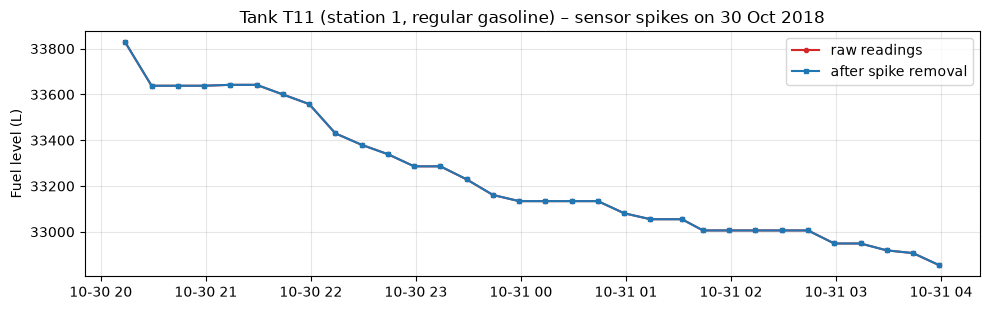

In [9]:
def remove_spikes(df, depth=SPIKE_L, max_h=1.0, passes=3):
    df = df.sort_values(["Tank ID", "Timestamp"]).reset_index(drop=True)
    removed = 0
    for _ in range(passes):
        g = df.groupby("Tank ID")
        prev_l, next_l = g["Fuel Level"].shift(1), g["Fuel Level"].shift(-1)
        prev_h = (df["Timestamp"] - g["Timestamp"].shift(1)).dt.total_seconds() / 3600
        next_h = (g["Timestamp"].shift(-1) - df["Timestamp"]).dt.total_seconds() / 3600
        spike = ((prev_l - df["Fuel Level"] > depth) & (next_l - df["Fuel Level"] > depth)
                 & (prev_h <= max_h) & (next_h <= max_h))
        if spike.sum() == 0:
            break
        removed += int(spike.sum())
        df = df[~spike].reset_index(drop=True)
    return df, removed

example = lv[(lv["Tank ID"] == "T11") & (lv["Timestamp"].between("2018-10-30 20:00", "2018-10-31 04:00"))]
lv, n_spikes = remove_spikes(lv)
log("Fuel levels", "Sensor spikes (reading >2,000 L below both neighbours within 1 h)", "Dropped", n_spikes)
print("Spike readings removed:", n_spikes)

example_after = lv[(lv["Tank ID"] == "T11") & (lv["Timestamp"].between("2018-10-30 20:00", "2018-10-31 04:00"))]
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(example["Timestamp"], example["Fuel Level"], "o-", ms=3, color="tab:red", label="raw readings")
ax.plot(example_after["Timestamp"], example_after["Fuel Level"], "s-", ms=3, color="tab:blue", label="after spike removal")
ax.set_title("Tank T11 (station 1, regular gasoline) – sensor spikes on 30 Oct 2018")
ax.set_ylabel("Fuel level (L)"); ax.legend(); plt.tight_layout(); plt.show()

#### Classifying each interval between consecutive readings

For every pair of consecutive readings of a tank the change in level is classified as one of:

| Type | Rule | Used for |
|---|---|---|
| `normal` | small change, interval ≤ 6 h | consumption = previous level − current level (tiny positive changes from sensor noise are allowed to net out) |
| `delivery` | level rises by ≥ 500 L | delivered volume = rise; consumption during that 15-minute interval is not observable (small loss, discussed in limitations) |
| `anomaly` | level falls by more than 2,000 L per hour-scaled interval without recovering (e.g. tank T15 drops 19,100 L in 15 min on 3 Dec 2018 and stays there) | excluded – cannot be sales; possibly a tank-to-tank transfer or gauge recalibration |
| `gap` | interval > 6 h | excluded |

Daily consumption per tank is the sum of `normal` consumption on that day; a day is **complete** when it has at least 20 hours of valid coverage and no anomaly. Station/fuel-type daily consumption is the sum over the station's tanks of that fuel, and is used only on days when *all* those tanks are complete.

In [10]:
grp = lv.groupby("Tank ID")
lv["Prev_Level"] = grp["Fuel Level"].shift(1)
lv["Gap_h"] = (lv["Timestamp"] - grp["Timestamp"].shift(1)).dt.total_seconds() / 3600
lv["Delta"] = lv["Fuel Level"] - lv["Prev_Level"]

draw_limit = MAX_DRAW_L * np.maximum(lv["Gap_h"].fillna(0), 1.0)
lv["Interval"] = np.select(
    [lv["Prev_Level"].isna(), lv["Gap_h"] > GAP_HOURS, lv["Delta"] >= DELIVERY_L, lv["Delta"] < -draw_limit],
    ["start", "gap", "delivery", "anomaly"], default="normal")
lv["Consumption"] = np.where(lv["Interval"] == "normal", -lv["Delta"], np.nan)
lv["Delivered"] = np.where(lv["Interval"] == "delivery", lv["Delta"], 0.0)
lv["Covered_h"] = np.where(lv["Interval"].isin(["normal", "delivery", "anomaly"]), lv["Gap_h"], 0.0)
lv["Date"] = lv["Timestamp"].dt.normalize()

print(lv["Interval"].value_counts().to_string())
anom = lv[lv["Interval"] == "anomaly"]
print("\nAnomalous drops (excluded from consumption):")
display(anom[["Tank ID", "Station", "Timestamp", "Prev_Level", "Fuel Level", "Delta", "Gap_h"]].round(2))
log("Fuel levels", "Unexplained sustained drops > plausible sales rate", "Interval excluded from consumption; day excluded from averages", len(anom))

Interval
normal      1853802
delivery       5524
gap             165
start            23
anomaly          11

Anomalous drops (excluded from consumption):


,Tank ID,Station,Timestamp,Prev_Level,Fuel Level,Delta,Gap_h
19212,T10,1,2017-07-21 05:59:00,19011.0,7969.0,-11042.0,0.75
144225,T11,1,2018-11-07 09:44:00,37824.0,31370.0,-6454.0,0.25
227330,T12,1,2018-10-31 00:14:00,29932.0,23709.0,-6223.0,0.25
230515,T12,1,2018-12-03 09:29:00,34039.0,23058.0,-10981.0,0.50
230516,T12,1,2018-12-03 09:44:00,23058.0,18689.0,-4369.0,0.25
299926,T13,1,2018-07-06 05:28:00,25386.0,7810.0,-17576.0,0.25
394847,T14,1,2018-10-31 00:14:00,31397.0,27055.0,-4342.0,0.25
437973,T15,1,2017-07-21 06:15:00,30776.0,25904.0,-4872.0,1.02
467170,T15,1,2018-07-06 05:13:00,27006.0,23906.0,-3100.0,0.25
481549,T15,1,2018-12-03 10:44:00,28509.0,9407.0,-19102.0,0.25


In [11]:
# Daily consumption per tank, then per station & fuel group
daily_tank = (lv.groupby(["Tank ID", "Station", "Fuel Group", "Date"])
                .agg(Consumption_L=("Consumption", "sum"), Delivered_L=("Delivered", "sum"),
                     Covered_h=("Covered_h", "sum"), Anomalies=("Interval", lambda s: (s == "anomaly").sum()))
                .reset_index())
daily_tank["Complete"] = (daily_tank["Covered_h"] >= MIN_COVER_H) & (daily_tank["Anomalies"] == 0)

daily_sf = (daily_tank.groupby(["Station", "Fuel Group", "Date"])
                      .agg(Consumption_L=("Consumption_L", "sum"), Delivered_L=("Delivered_L", "sum"),
                           N_complete=("Complete", "sum"))
                      .reset_index()
                      .merge(capacity[["Station", "Fuel Group", "N_Tanks", "Total_Capacity_L"]], on=["Station", "Fuel Group"]))
daily_sf["Complete"] = daily_sf["N_complete"] == daily_sf["N_Tanks"]

print("Share of station-fuel days that are complete:", f"{daily_sf['Complete'].mean():.1%}")
display(daily_sf.groupby(["Station", "Fuel Group"])["Complete"].agg(["sum", "size"])
        .rename(columns={"sum": "Complete days", "size": "Days with readings"}).T)

Share of station-fuel days that are complete: 98.5%


Station               1         2         3         4         5         6         7         8     
Fuel Group            D    G    D    G    D    G    D    G    D    G    D    G    D    G    D    G
Complete days       862  859  907  907  704  704  868  869  905  905  893  893  724  724  823  857
Days with readings  882  882  914  914  718  718  881  881  913  913  901  901  737  737  839  872

#### Cleaning log

In [12]:
display(pd.DataFrame(cleaning_log))

,Dataset,Issue,Rows affected,Action
0,Locations,Lat/long inconsistent with address (station 8),1,Kept; coordinates are not used in calculations
1,Invoices,"Blank rows (no cost/quantity/fuel), incl. 5 ro...",42,Dropped
2,Invoices,Exact duplicate rows,0,Dropped
3,Invoices,Delivery larger than station capacity,0,None found
4,Fuel levels,Missing level or unparseable timestamp,2,Dropped
5,Fuel levels,Exact duplicate readings,71,Dropped
6,Fuel levels,Same tank & timestamp with different levels,48,Kept the last reading
7,Fuel levels,Unknown tank ID,0,Dropped
8,Fuel levels,Negative level,0,Dropped
9,Fuel levels,Level above tank capacity,0,Dropped


## 2. Business Question 1 – Evaluate current inventory management

### 2.1 Fuel levels over time for each tank

Each panel shows the hourly average level of one tank over the whole period, with the tank capacity as a dashed line. The saw-tooth pattern is the normal purchase cycle: a vertical rise is a delivery, the downward slope is sales. Flat segments are periods with no readings (data gaps), not periods with no sales.

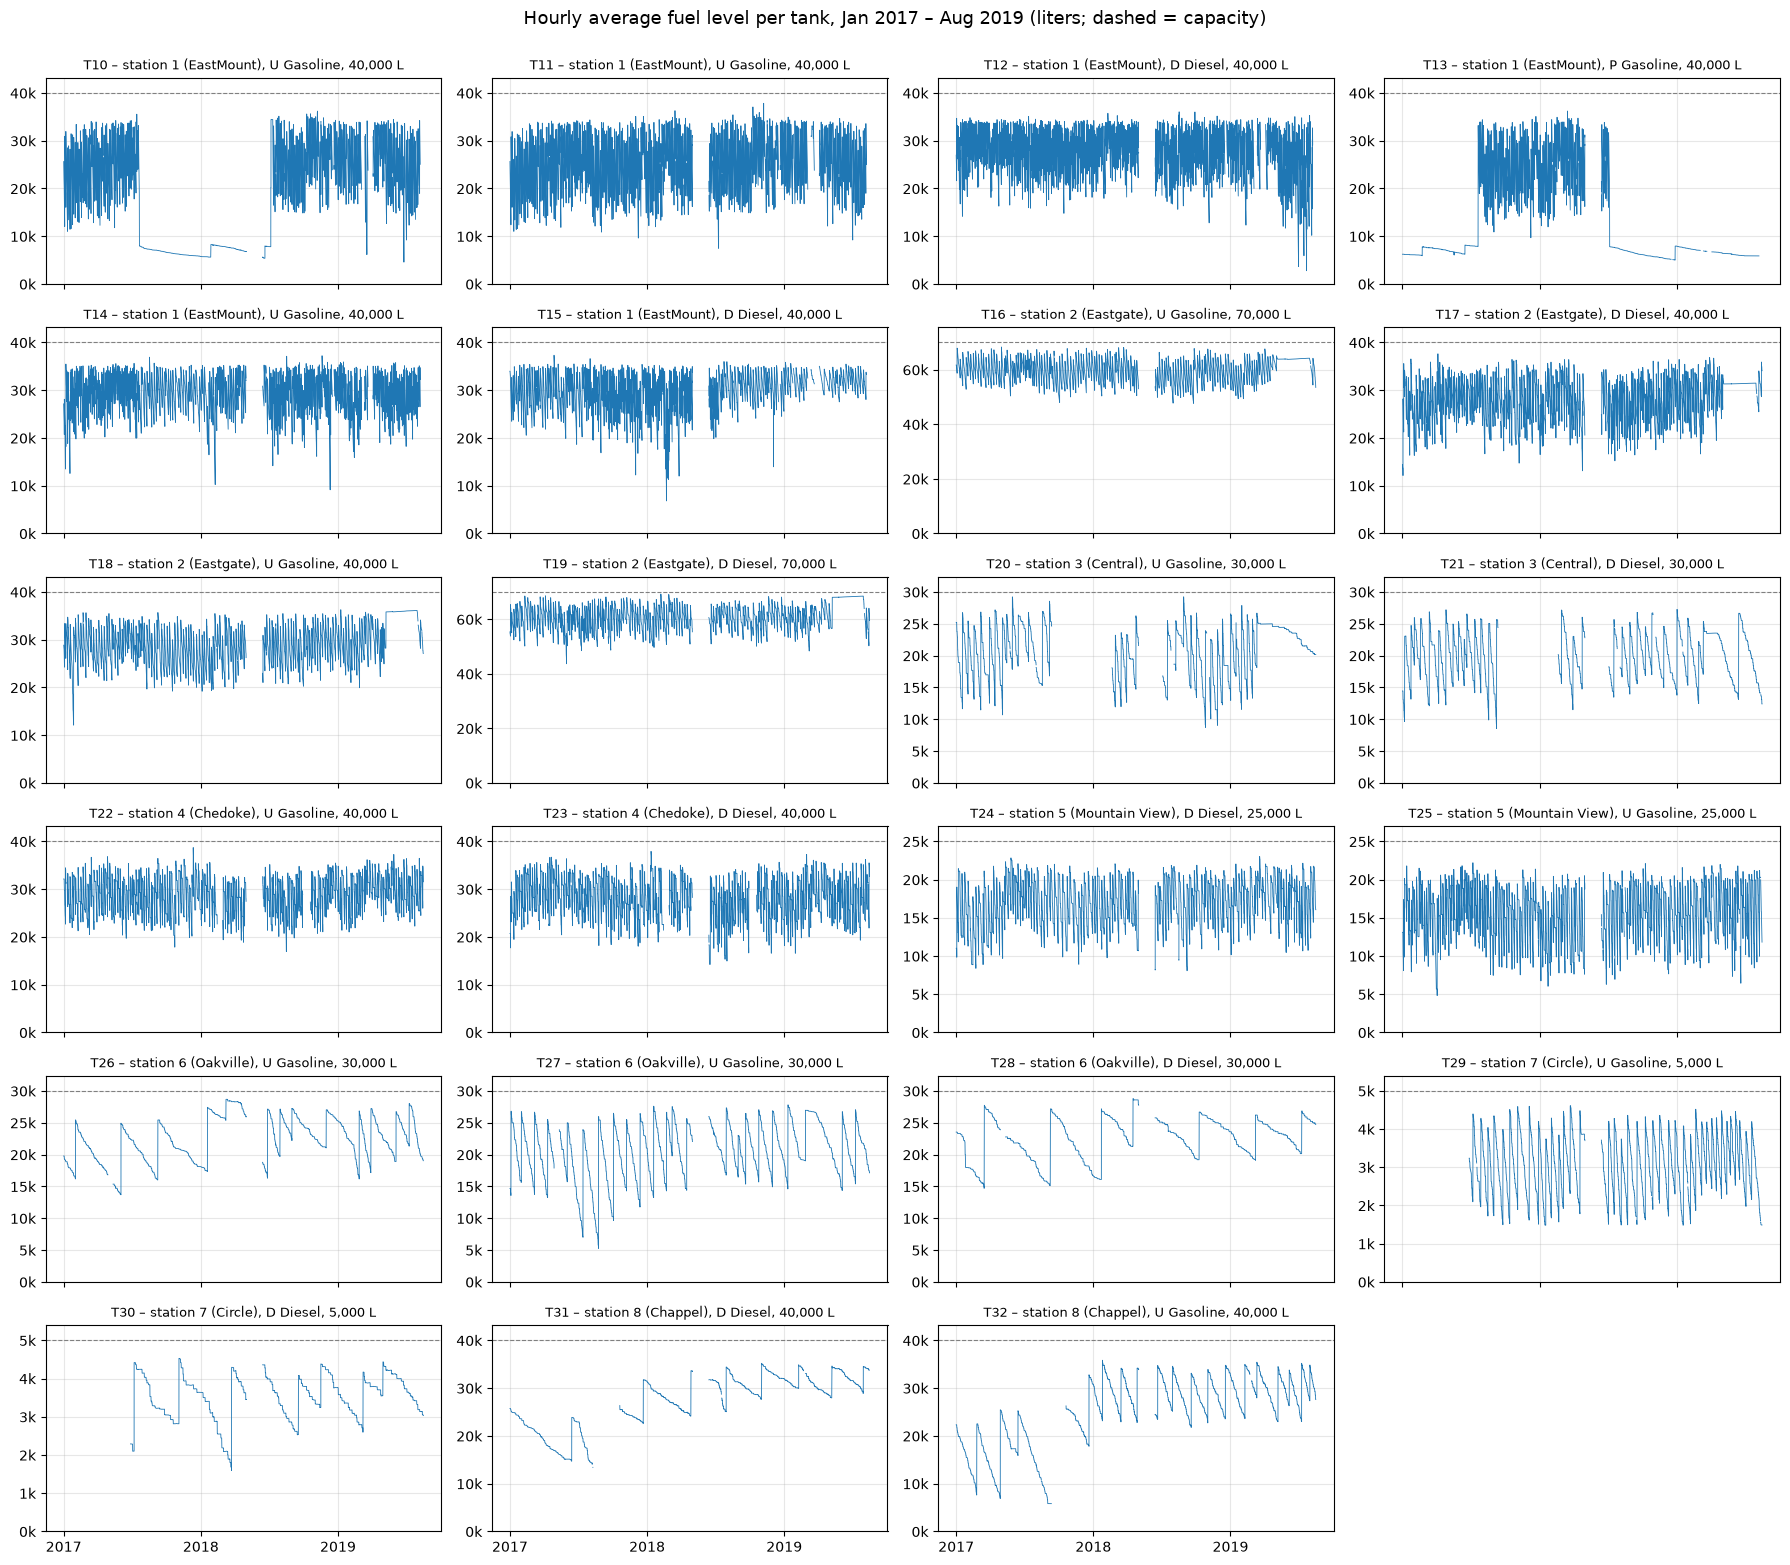

In [13]:
hourly = (lv.set_index("Timestamp").groupby("Tank ID")["Fuel Level"]
            .resample("1h").mean().reset_index())
tank_order = tanks.sort_values(["Station", "Tank Number"])["Tank ID"].tolist()
ncol = 4; nrow = math.ceil(len(tank_order) / ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(18, 2.6 * nrow), sharex=True)
for ax, tid in zip(axes.flat, tank_order):
    d = hourly[hourly["Tank ID"] == tid]
    t = tanks.set_index("Tank ID").loc[tid]
    ax.plot(d["Timestamp"], d["Fuel Level"], lw=0.6, color="tab:blue")
    ax.axhline(t["Tank Capacity"], ls="--", color="grey", lw=0.8)
    ax.set_title(f"{tid} – station {t['Station']} ({locations.set_index('Station').loc[t['Station'],'Station Name']}), "
                 f"{t['Tank Type']} {FUEL_NAME[t['Fuel Group']]}, {t['Tank Capacity']:,} L", fontsize=9)
    ax.set_ylim(0, t["Tank Capacity"] * 1.08)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
for ax in axes.flat[len(tank_order):]:
    ax.axis("off")
for ax in axes[-1]:
    ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("Hourly average fuel level per tank, Jan 2017 – Aug 2019 (liters; dashed = capacity)", y=1.0, fontsize=13)
plt.tight_layout(); plt.show()

A two-week zoom on station 1 makes individual replenishment events visible.

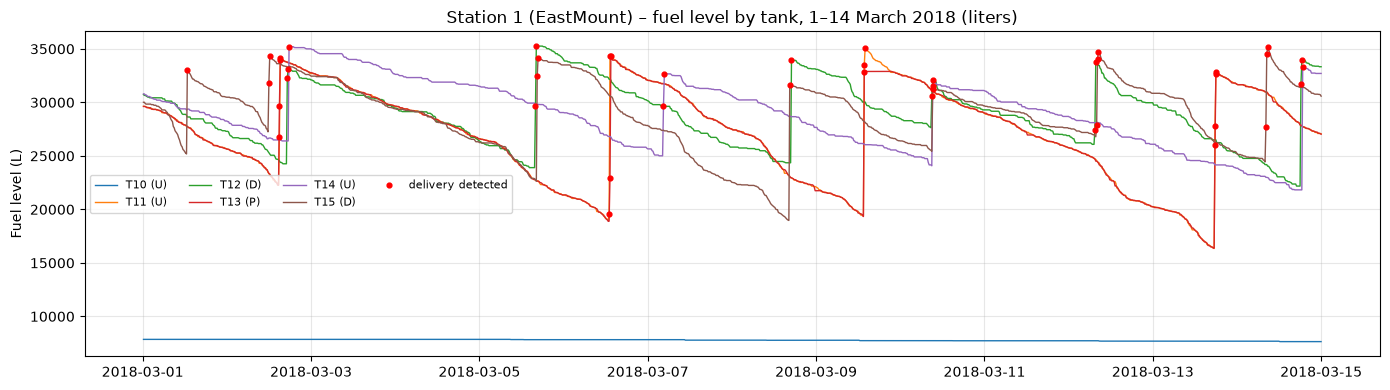

In [14]:
zoom = lv[(lv["Station"] == 1) & (lv["Timestamp"].between("2018-03-01", "2018-03-15"))]
fig, ax = plt.subplots(figsize=(14, 4))
for tid, d in zoom.groupby("Tank ID"):
    t = tanks.set_index("Tank ID").loc[tid]
    ax.plot(d["Timestamp"], d["Fuel Level"], lw=1, label=f"{tid} ({t['Tank Type']})")
deliv = zoom[zoom["Interval"] == "delivery"]
ax.scatter(deliv["Timestamp"], deliv["Fuel Level"], color="red", s=12, zorder=5, label="delivery detected")
ax.set_title("Station 1 (EastMount) – fuel level by tank, 1–14 March 2018 (liters)")
ax.set_ylabel("Fuel level (L)"); ax.legend(ncol=4, fontsize=8); plt.tight_layout(); plt.show()

### 2.2 Replenishment events, low-inventory periods and stockout risk

To analyse inventory at the level at which orders are placed (station × fuel type), each tank's readings are placed on a common 15-minute grid (forward-filled for at most 2 hours) and summed across the station's tanks of that fuel type. A **replenishment event** is a rise of at least 500 L in the station total between consecutive grid points (consecutive rises are merged into one event).

In [15]:
lv["T15"] = lv["Timestamp"].dt.floor("15min")
wide = (lv.groupby(["T15", "Tank ID"])["Fuel Level"].last().unstack("Tank ID"))
full_idx = pd.date_range(wide.index.min(), wide.index.max(), freq="15min")
wide = wide.reindex(full_idx).ffill(limit=8)   # fill at most 2 hours

sf_keys = capacity[["Station", "Fuel Group"]].values.tolist()
sf_level = {}
for st, fg in sf_keys:
    cols = tanks[(tanks["Station"] == st) & (tanks["Fuel Group"] == fg)]["Tank ID"].tolist()
    sf_level[(st, fg)] = wide[cols].sum(axis=1, skipna=False)
sf_level = pd.DataFrame(sf_level)
sf_level.columns = pd.MultiIndex.from_tuples(sf_level.columns, names=["Station", "Fuel Group"])
print("Station/fuel inventory grid:", sf_level.shape)

# Replenishment events on the station/fuel series
events = []
for key in sf_level.columns:
    s = sf_level[key]
    rise = s.diff()
    is_del = rise >= DELIVERY_L
    event_id = (is_del & ~is_del.shift(1, fill_value=False)).cumsum()
    ev = (pd.DataFrame({"rise": rise[is_del], "before": s.shift(1)[is_del], "event": event_id[is_del]})
            .groupby("event").agg(Time=("rise", lambda x: x.index[0]), Delivered_L=("rise", "sum"), Level_before_L=("before", "first")))
    ev["Station"], ev["Fuel Group"] = key
    events.append(ev)
events = pd.concat(events, ignore_index=True)
print("Replenishment events detected:", len(events))

Station/fuel inventory grid: (91872, 16)
Replenishment events detected: 2346


### 2.3 Daily consumption by station and fuel type

Average daily consumption is the mean of the complete-day station/fuel totals from section 1.4. As a validation, the table compares (a) total consumption inferred from the gauges, (b) delivered volume inferred from the gauges and (c) invoiced volume over the same period. They should agree except where readings are missing (station 3 has the largest gaps) or during the May–June 2018 outage.

In [16]:
cons_stats = (daily_sf[daily_sf["Complete"]]
              .groupby(["Station", "Fuel Group"])["Consumption_L"]
              .agg(Avg_Daily_L="mean", Std_Daily_L="std", P95_Daily_L=lambda s: s.quantile(0.95),
                   Max_Daily_L="max", Complete_Days="count"))

In [17]:
# worst 7 consecutive complete days (for the demand-variability discussion in Q2)
m7 = {}
for key, df in daily_sf.groupby(["Station", "Fuel Group"]):
    s = df.set_index("Date")["Consumption_L"].where(df.set_index("Date")["Complete"])
    s = s.reindex(pd.date_range(s.index.min(), s.index.max(), freq="D"))
    m7[key] = s.rolling(7, min_periods=7).sum().max()
cons_stats["Max_7day_L"] = pd.Series(m7)

# validation against invoices and gauge-detected deliveries
val = (daily_sf.groupby(["Station", "Fuel Group"]).agg(Gauge_Consumption_L=("Consumption_L", "sum"),
                                                        Gauge_Deliveries_L=("Delivered_L", "sum"))
         .join(inv.groupby(["Station", "Fuel Type"])["Liters"].sum().rename("Invoiced_L")
                  .rename_axis(["Station", "Fuel Group"])))
val["Deliveries vs invoices"] = val["Gauge_Deliveries_L"] / val["Invoiced_L"] - 1
val["Consumption vs invoices"] = val["Gauge_Consumption_L"] / val["Invoiced_L"] - 1
display(cons_stats.round(0).astype({"Complete_Days": int}))
display(val.round(3).style.format({"Gauge_Consumption_L": "{:,.0f}", "Gauge_Deliveries_L": "{:,.0f}", "Invoiced_L": "{:,.0f}",
                                   "Deliveries vs invoices": "{:+.1%}", "Consumption vs invoices": "{:+.1%}"}))

Avg_Daily_L  Std_Daily_L  P95_Daily_L  Max_Daily_L  Complete_Days  Max_7day_L
Station Fuel Group                                                                               
1       D                7080.0       2172.0      10990.0      15032.0            862     83543.0
        G               12484.0       2831.0      16656.0      23397.0            859    109237.0
2       D                4098.0       2594.0       7579.0      10077.0            907     43304.0
        G                3146.0       1570.0       5103.0       7457.0            907     29519.0
3       D                 450.0        429.0       1194.0       2017.0            704      6238.0
        G                 512.0        633.0       1734.0       2911.0            704      8180.0
4       D                2087.0       1676.0       4833.0       7446.0            868     24776.0
        G                1897.0       1356.0       3505.0       4951.0            869     17208.0
5       D                1043.0        830.0       2296.0       3921.0            905     13525.0
        G                1538.0       1106.0       2940.0       3864.0            905     16858.0
6       D                  67.0        145.0        297.0       2006.0            893      4838.0
        G                 434.0        360.0        997.0       1514.0            893      4940.0
7       D                  16.0         41.0        108.0        316.0            724       548.0
        G                 124.0         87.0        271.0        495.0            724      1388.0
8       D                  74.0        132.0        348.0        897.0            823      2779.0
        G                 243.0        219.0        599.0       1026.0            857      3415.0

**The invoice file appears incomplete.** Gauge-inferred diesel throughput exceeds invoiced diesel by 8–27 % at stations 1, 2, 4, 5 and 6, while gasoline agrees within about 1–5 % over the full period. The quarterly comparison below shows that the diesel shortfall is persistent, and that from Q2 2019 invoices for *both* fuels cover only about 60 % of the gauge-measured deliveries. Gauge-detected deliveries and gauge-inferred consumption agree closely with each other, so this points to invoices missing from the supplied file (the brief notes that invoice details were altered) rather than a gauge problem. Consequences for this analysis: consumption, reserves and the policy simulation use the gauge data, which is complete apart from the documented gaps, while the discount comparisons "on the same total volume" use invoiced volume, so the diesel and 2019 savings reported in Questions 2 and 4 are conservative.

In [18]:
q = (daily_sf.groupby(["Fuel Group", pd.Grouper(key="Date", freq="QS")])["Delivered_L"].sum().rename("Gauge_Deliveries_L").to_frame()
       .join(inv.set_index("Date").groupby(["Fuel Type", pd.Grouper(level="Date", freq="QS")])["Liters"].sum()
                .rename_axis(["Fuel Group", "Date"]).rename("Invoiced_L")))
q["Gauge / invoiced"] = q["Gauge_Deliveries_L"] / q["Invoiced_L"]
q = q["Gauge / invoiced"].unstack("Fuel Group").rename(columns=FUEL_NAME)
q.index = q.index.to_period("Q").astype(str)
display(q.round(2).T.style.format("{:.2f}").set_caption("Ratio of gauge-detected deliveries to invoiced volume, by quarter (1.00 = perfect agreement; Q2 2018 is low because of the 44-day gauge outage)"))

Date,2017Q1,2017Q2,2017Q3,2017Q4,2018Q1,2018Q2,2018Q3,2018Q4,2019Q1,2019Q2,2019Q3
Fuel Group,,,,,,,,,,,
Diesel,1.34,1.23,1.19,1.18,1.14,0.62,1.07,1.02,1.26,2.25,1.68
Gasoline,1.21,1.02,0.89,0.92,0.93,0.51,1.02,1.06,1.16,1.65,1.57


**Method limitations.** Consumption is inferred from gauge differences, so (i) sales during the 15 minutes in which a delivery is pumped are not observed, (ii) sales during data gaps are unobserved and those days are excluded from the averages, (iii) gauge noise of a few liters per reading nets out over a day but adds variance, and (iv) unexplained sustained drops (section 1.4) are excluded rather than interpreted. Agreement between gauge-inferred deliveries and invoiced volume is within a few percent for most station/fuel pairs, which supports the method; station 3's shortfall is explained by its two long gaps.

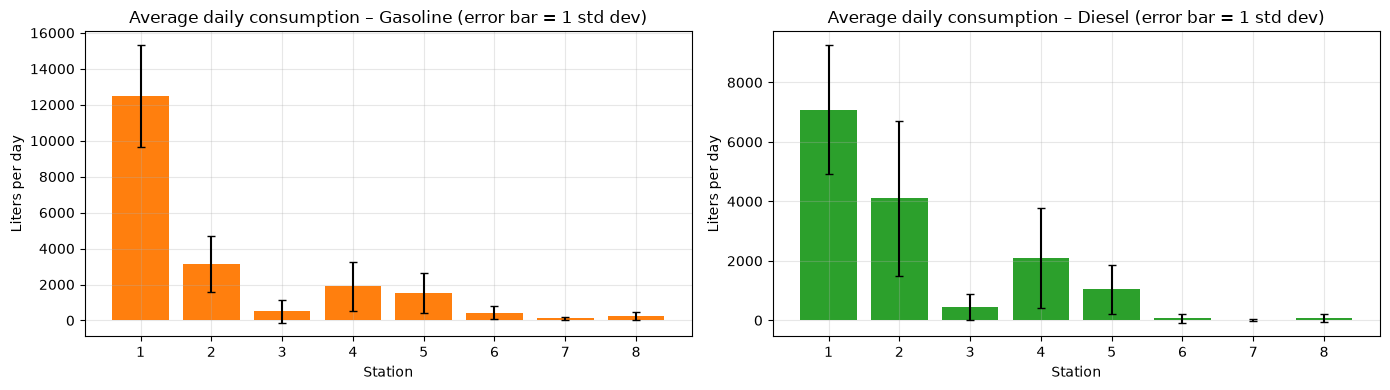

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, fg in zip(axes, ["G", "D"]):
    d = cons_stats.xs(fg, level="Fuel Group")
    ax.bar(d.index.astype(str), d["Avg_Daily_L"], yerr=d["Std_Daily_L"], capsize=3, color="tab:orange" if fg == "G" else "tab:green")
    ax.set_title(f"Average daily consumption – {FUEL_NAME[fg]} (error bar = 1 std dev)")
    ax.set_xlabel("Station"); ax.set_ylabel("Liters per day")
plt.tight_layout(); plt.show()

### 2.4 Inventory position: how low do stations let inventory fall?

Using the station/fuel inventory grid, the table reports how often total inventory for a fuel type was below the seven-day reserve (7 × average daily consumption), below 10 % of capacity, the minimum level ever recorded, and the typical inventory level at the moment a delivery arrived (the station's *de facto* reorder point).

In [20]:
pos = []
for key in sf_level.columns:
    st, fg = key
    s = sf_level[key].dropna()
    avg = cons_stats.loc[key, "Avg_Daily_L"]
    cap = capacity.set_index(["Station", "Fuel Group"]).loc[key, "Total_Capacity_L"]
    reserve = RESERVE_DAYS * avg
    below_res = (s < reserve)
    ev = events[(events["Station"] == st) & (events["Fuel Group"] == fg)]
    pos.append({"Station": st, "Fuel Group": fg, "Capacity_L": cap, "Avg_Daily_L": avg, "Reserve_7d_L": reserve,
                "Share_time_below_reserve": below_res.mean(),
                "Share_time_below_10pct_cap": (s < 0.1 * cap).mean(),
                "Min_level_L": s.min(), "Min_level_days_cover": s.min() / avg,
                "N_deliveries_detected": len(ev),
                "Avg_level_at_delivery_L": ev["Level_before_L"].mean(),
                "Avg_days_cover_at_delivery": ev["Level_before_L"].mean() / avg,
                "Avg_delivered_L": ev["Delivered_L"].mean()})
pos = pd.DataFrame(pos).set_index(["Station", "Fuel Group"])
display(pos.style.format({"Capacity_L": "{:,.0f}", "Avg_Daily_L": "{:,.0f}", "Reserve_7d_L": "{:,.0f}",
                          "Share_time_below_reserve": "{:.1%}", "Share_time_below_10pct_cap": "{:.1%}",
                          "Min_level_L": "{:,.0f}", "Min_level_days_cover": "{:.1f}", "N_deliveries_detected": "{:.0f}",
                          "Avg_level_at_delivery_L": "{:,.0f}", "Avg_days_cover_at_delivery": "{:.1f}", "Avg_delivered_L": "{:,.0f}"}))

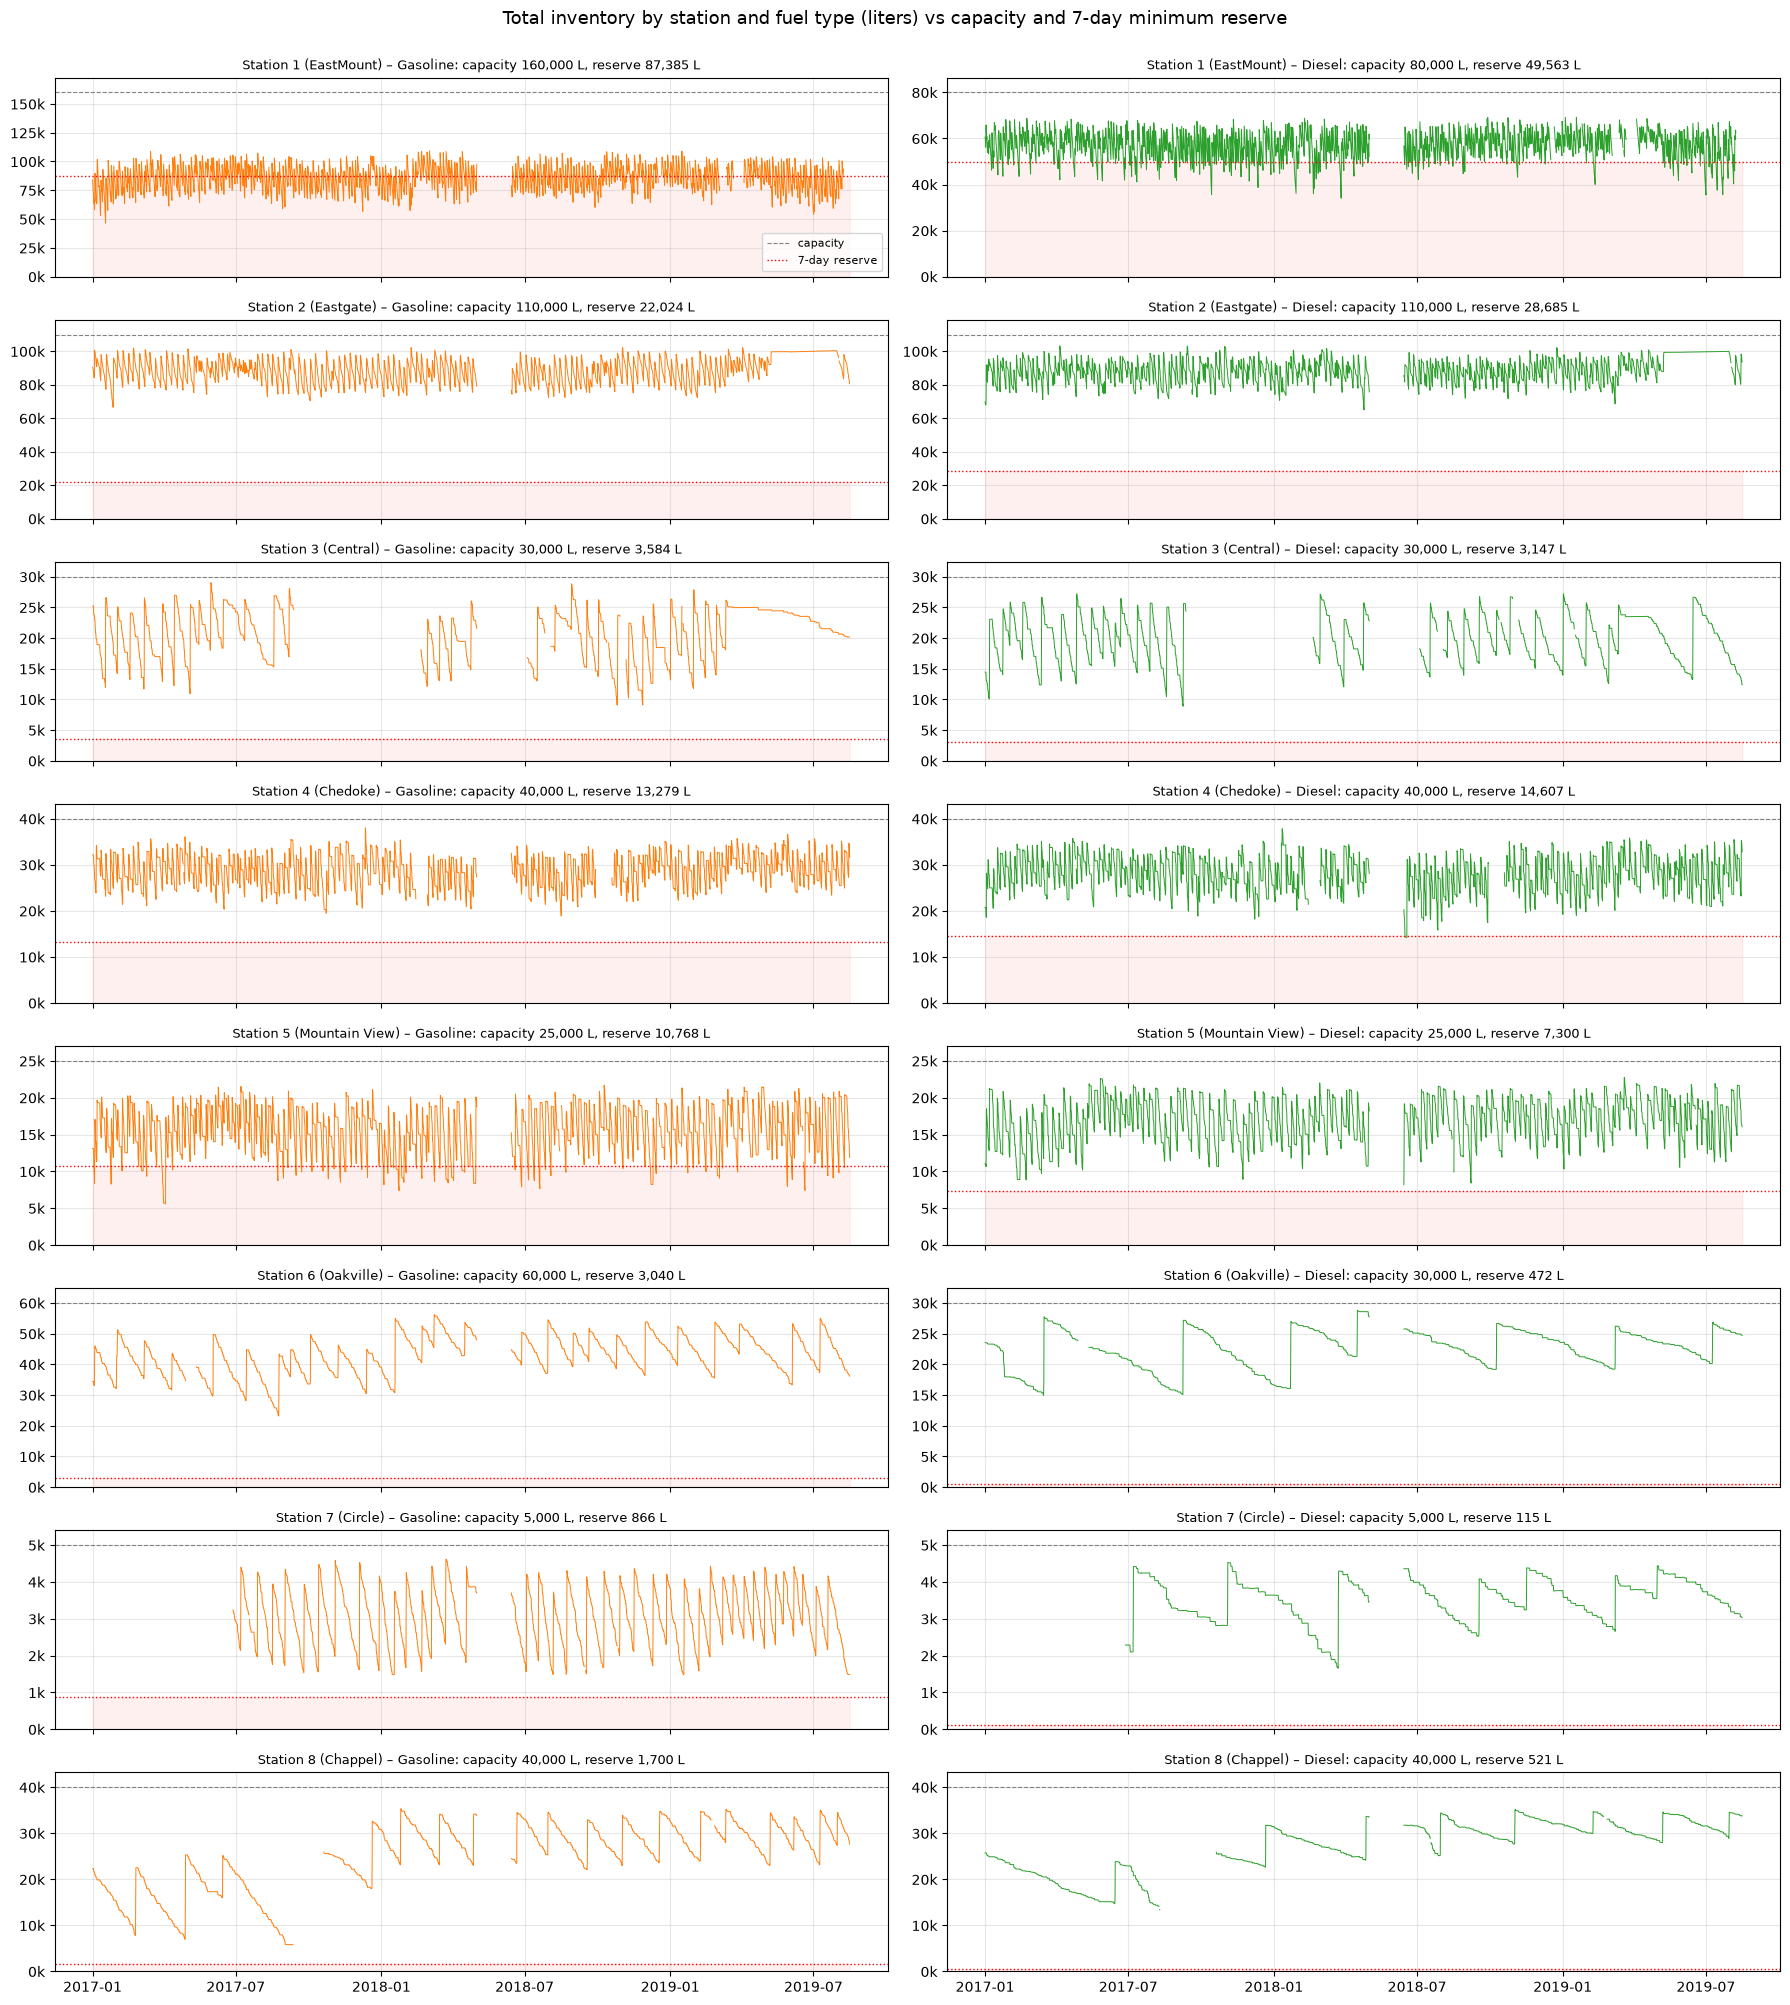

In [21]:
fig, axes = plt.subplots(8, 2, figsize=(18, 20), sharex=True)
for i, st in enumerate(STATIONS):
    for j, fg in enumerate(["G", "D"]):
        ax = axes[i, j]
        if (st, fg) not in sf_level.columns:
            ax.axis("off"); continue
        s = sf_level[(st, fg)].resample("6h").mean()
        cap = capacity.set_index(["Station", "Fuel Group"]).loc[(st, fg), "Total_Capacity_L"]
        res = pos.loc[(st, fg), "Reserve_7d_L"]
        ax.plot(s.index, s.values, lw=0.7, color="tab:orange" if fg == "G" else "tab:green")
        ax.axhline(cap, ls="--", color="grey", lw=0.8, label="capacity")
        ax.axhline(res, ls=":", color="red", lw=1, label="7-day reserve")
        ax.fill_between(s.index, 0, res, color="red", alpha=0.06)
        ax.set_title(f"Station {st} ({locations.set_index('Station').loc[st, 'Station Name']}) – {FUEL_NAME[fg]}: "
                     f"capacity {cap:,.0f} L, reserve {res:,.0f} L", fontsize=9)
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
        ax.set_ylim(0, cap * 1.08)
        if i == 0 and j == 0: ax.legend(fontsize=8, loc="lower right")
        ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7])); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.suptitle("Total inventory by station and fuel type (liters) vs capacity and 7-day minimum reserve", fontsize=13, y=1.0)
plt.tight_layout(); plt.show()

### 2.5 Current purchasing performance (stations 1–8)

Invoice quantities, order frequency, purchase cost per liter and the discounts actually achieved. Discount savings = liters × applicable discount per liter for each delivery.

In [22]:
months_obs = OBS_DAYS / 30.44
perf = (inv.groupby(["Station", "Fuel Type"])
           .agg(N_Orders=("Invoice ID", "count"), Total_L=("Liters", "sum"), Avg_Order_L=("Liters", "mean"),
                Median_Order_L=("Liters", "median"), Max_Order_L=("Liters", "max"),
                Total_Cost_CAD=("Cost_CAD", "sum"), Discount_Savings_CAD=("Discount_Savings_CAD", "sum"))
           .rename_axis(["Station", "Fuel Group"]))
perf["Orders_per_Month"] = perf["N_Orders"] / months_obs
perf["Avg_Cost_per_L"] = perf["Total_Cost_CAD"] / perf["Total_L"]
perf["Avg_Discount_cents_per_L"] = perf["Discount_Savings_CAD"] / perf["Total_L"] * 100
tier_mix = (inv.groupby(["Station", "Fuel Type"])["Tier"].value_counts(normalize=True).unstack("Tier")
              .reindex(columns=TIER_ORDER).fillna(0).rename_axis(["Station", "Fuel Group"]))
perf = perf.join(tier_mix.add_prefix("Share "))
display(perf.style.format({"Total_L": "{:,.0f}", "Avg_Order_L": "{:,.0f}", "Median_Order_L": "{:,.0f}", "Max_Order_L": "{:,.0f}",
                           "Total_Cost_CAD": "{:,.0f}", "Discount_Savings_CAD": "{:,.0f}", "Orders_per_Month": "{:.1f}",
                           "Avg_Cost_per_L": "{:.3f}", "Avg_Discount_cents_per_L": "{:.2f}",
                           **{f"Share {t}": "{:.0%}" for t in TIER_ORDER}}))
print(f"Network total over {OBS_DAYS} days: {inv['Liters'].sum():,.0f} L purchased for CAD {inv['Cost_CAD'].sum():,.0f}; "
      f"discount savings achieved CAD {inv['Discount_Savings_CAD'].sum():,.0f} "
      f"({inv['Discount_Savings_CAD'].sum()/inv['Liters'].sum()*100:.2f} cents per liter on average).")

Network total over 956 days: 29,076,698 L purchased for CAD 33,298,726; discount savings achieved CAD 205,979 (0.71 cents per liter on average).


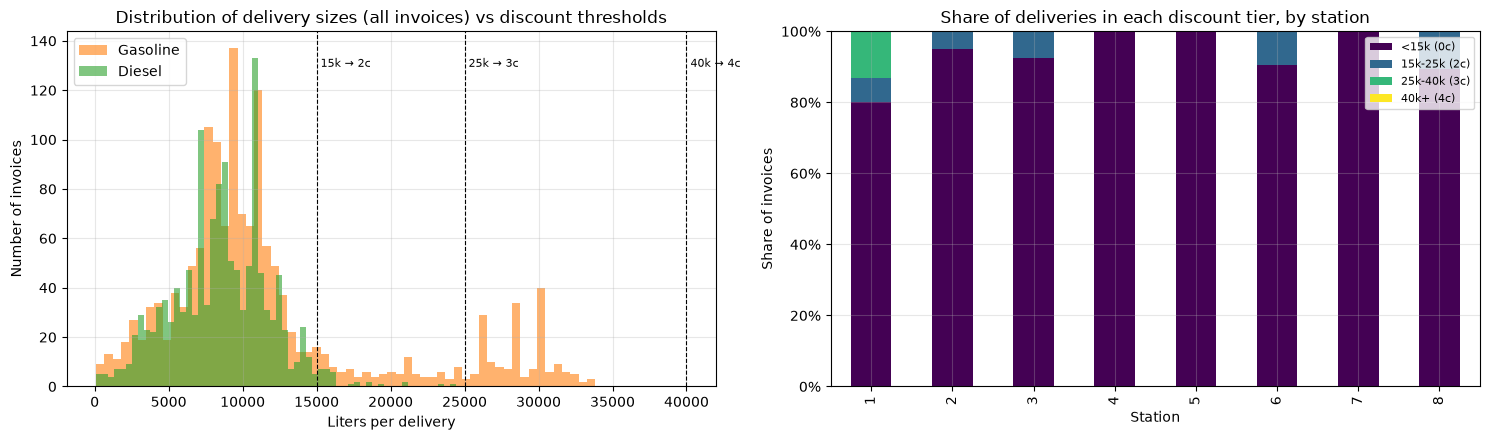

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
ax = axes[0]
for fg, col in [("G", "tab:orange"), ("D", "tab:green")]:
    ax.hist(inv[inv["Fuel Type"] == fg]["Liters"], bins=60, alpha=0.6, color=col, label=FUEL_NAME[fg])
for thr, lab in [(15000, "2c"), (25000, "3c"), (40000, "4c")]:
    ax.axvline(thr, ls="--", color="black", lw=0.8); ax.text(thr, ax.get_ylim()[1]*0.9, f" {thr/1000:.0f}k → {lab}", fontsize=8)
ax.set_title("Distribution of delivery sizes (all invoices) vs discount thresholds"); ax.set_xlabel("Liters per delivery"); ax.set_ylabel("Number of invoices"); ax.legend()
ax = axes[1]
tm = inv.groupby("Station")["Tier"].value_counts(normalize=True).unstack("Tier").reindex(columns=TIER_ORDER).fillna(0)
tm.plot(kind="bar", stacked=True, ax=ax, colormap="viridis")
ax.set_title("Share of deliveries in each discount tier, by station"); ax.set_ylabel("Share of invoices"); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=8, loc="upper right"); plt.tight_layout(); plt.show()

### 2.6 Findings – current inventory management

* **The network buys small and often.** Of the 2,831 valid deliveries, 89 % are below 15,000 L (73 % of all volume) and earn no discount at all; only 6 % reach 25,000 L and **no delivery ever reached the 40,000 L tier** (largest delivery: 33,827 L). Discount savings achieved over the 956-day period are CAD 205,979, or 0.71 cents per liter on 29.1 million liters. Station 1 gasoline is the only station/fuel pair that regularly earns a discount (23 % of its orders in the 3-cent tier); stations 4, 5 and 7 earned essentially nothing.
* **Station 1 (EastMount) is the outlier in both directions.** It takes a delivery almost every day (24 gasoline and 19 diesel orders per month, average 14,300 L and 8,100 L) yet runs lean: total gasoline inventory sat below the seven-day reserve 53 % of the time and the station typically reorders with about 6 days of cover left (minimum observed 3.4 days). Its diesel inventory was below reserve 12 % of the time. This is the station with real stockout exposure if a delivery is late.
* **Station 5 gasoline (Mountain View)** is the second risk: two 25,000 L tanks against 1,540 L/day of demand, inventory below reserve 10 % of the time and a minimum of 3.1 days of cover.
* **Stations 2, 3, 6 and 8 carry far more fuel than they need** relative to demand: they reorder with 15–30 days of cover (station 6 diesel: about 270 days) and never approach the reserve. Their problem is not stockout risk but that they still order in sub-discount quantities.
* **Daily demand** ranges from about 12,500 L of gasoline per day at station 1 to under 20 L of diesel per day at station 7. Gauge-inferred consumption agrees with gauge-detected deliveries within 1–3 % everywhere, which validates the method; the shortfall of invoiced volume against both (diesel throughout, both fuels in 2019) is a property of the invoice file, discussed above.
* **Station 1 rotates two of its gasoline tanks.** T10 and T13 are never in active use at the same time: T10 is idle (flat at 5,000–8,000 L) from July 2017 to June 2018 while T13 is active, and the roles are reversed before and after. The station-level analysis is unaffected because inventory is summed across tanks, but it means station 1's *effective* gasoline capacity is closer to 120,000 L than the nominal 160,000 L whenever one tank is kept idle.
* **Replenishment events** detected from the gauges (2,346) are fewer than invoices (2,831) because several invoices on the same day for the same fuel show up as a single rise in inventory.

## 3. Business Question 2 – Recommend improved ordering strategies

### 3.1 Capacity, consumption, reserve and available storage

For each station and fuel type:

* minimum reserve = 7 × average daily consumption;
* available storage at the reserve level = total capacity − minimum reserve (orders are delivered immediately, so the tank is at the reserve level when the delivery arrives);
* the **attainable discount tier** is the highest threshold that fits within available storage. Total capacity alone is not enough: a 40,000 L station with heavy demand may only have room for a 25,000 L order once the reserve is held back.

In [24]:
policy = (capacity.set_index(["Station", "Fuel Group"])[["Total_Capacity_L"]]
          .join(cons_stats[["Avg_Daily_L", "Std_Daily_L", "P95_Daily_L", "Max_7day_L"]]))
policy["Reserve_7d_L"] = RESERVE_DAYS * policy["Avg_Daily_L"]
policy["Available_L"] = policy["Total_Capacity_L"] - policy["Reserve_7d_L"]
policy["Feasible"] = policy["Available_L"] > 0

def best_tier_qty(avail):
    '''Largest discount threshold that fits in the available storage (0 if none).'''
    for thr, rate in DISCOUNT_TIERS:
        if thr > 0 and avail >= thr:
            return thr
    return 0

policy["Best_Tier_Qty_L"] = policy["Available_L"].apply(best_tier_qty)
policy["Best_Tier_Rate"] = policy["Best_Tier_Qty_L"].apply(discount_rate)
policy["Reserve_vs_Capacity"] = policy["Reserve_7d_L"] / policy["Total_Capacity_L"]
display(policy.style.format({"Total_Capacity_L": "{:,.0f}", "Avg_Daily_L": "{:,.0f}", "Std_Daily_L": "{:,.0f}", "P95_Daily_L": "{:,.0f}",
                             "Max_7day_L": "{:,.0f}", "Reserve_7d_L": "{:,.0f}", "Available_L": "{:,.0f}",
                             "Best_Tier_Qty_L": "{:,.0f}", "Best_Tier_Rate": "{:.2f}", "Reserve_vs_Capacity": "{:.0%}"}))
infeasible = policy[~policy["Feasible"]]
print("Station/fuel pairs where the 7-day reserve equals or exceeds capacity:", len(infeasible))

Station/fuel pairs where the 7-day reserve equals or exceeds capacity: 0


### 3.2 Comparing feasible order quantities

For each station and fuel type, four candidate order quantities are compared: 15,000 L, 25,000 L, 40,000 L and "fill-up" (order exactly the available storage). A scenario is feasible only if the quantity fits within available storage when delivered at the reserve level. The table shows the discount each scenario earns, how many days of demand it covers (= order quantity ÷ average daily consumption, i.e. the time between orders) and the discount savings it would generate on the station's observed total volume.

In [25]:
scen_rows = []
for key, r in policy.iterrows():
    vol = perf.loc[key, "Total_L"]
    for name, q in [("15,000 L", 15000), ("25,000 L", 25000), ("40,000 L", 40000), ("Fill-up (available storage)", r["Available_L"])]:
        feasible = (q <= r["Available_L"]) and (q > 0)
        scen_rows.append({"Station": key[0], "Fuel Group": key[1], "Scenario": name, "Order_Qty_L": q,
                          "Feasible": feasible, "Discount_per_L": discount_rate(q) if feasible else np.nan,
                          "Days_between_orders": q / r["Avg_Daily_L"] if feasible else np.nan,
                          "Orders_per_year": 365 * r["Avg_Daily_L"] / q if feasible else np.nan,
                          "Savings_on_observed_volume_CAD": vol * discount_rate(q) if feasible else np.nan})
scenarios = pd.DataFrame(scen_rows)
scen_table = scenarios.pivot_table(index=["Station", "Fuel Group"], columns="Scenario",
                                   values=["Feasible", "Discount_per_L", "Days_between_orders"], aggfunc="first")
display(scenarios.pivot(index=["Station", "Fuel Group"], columns="Scenario", values="Savings_on_observed_volume_CAD")
        .style.format("{:,.0f}", na_rep="not feasible").set_caption("Discount savings over the observed period by scenario (CAD); 'not feasible' = does not fit within available storage"))
display(scenarios.pivot(index=["Station", "Fuel Group"], columns="Scenario", values="Days_between_orders")
        .style.format("{:.1f}", na_rep="not feasible").set_caption("Days between orders under each scenario"))

### 3.3 Recommended policy and savings

**Decision rule.** For each station and fuel type, place an order when total inventory of that fuel reaches the seven-day reserve, and order the *smallest quantity that earns the best attainable discount*. Larger orders up to the fill-up quantity earn the same discount per liter but tie up more cash, so the threshold quantity is preferred; where no threshold fits (station 7), the recommendation is to fill to capacity because no discount is available in any case.

Savings are computed on the **same total volume** each station actually purchased in the observed period:

* *current savings* – the discounts actually earned (section 2.5);
* *proposed-policy savings* – observed volume × attainable discount per liter;
* *theoretical upper bound* – observed volume × 4 cents, which would require every delivery to be ≥ 40,000 L and is impossible wherever available storage is below 40,000 L.

In [26]:
rec = policy.copy()
rec["Recommended_Qty_L"] = np.where(rec["Best_Tier_Qty_L"] > 0, rec["Best_Tier_Qty_L"], rec["Available_L"].clip(lower=0))
rec["Recommended_Rate"] = rec["Recommended_Qty_L"].apply(discount_rate)
rec["Trigger_L"] = rec["Reserve_7d_L"]
rec["Days_between_orders"] = rec["Recommended_Qty_L"] / rec["Avg_Daily_L"]
rec["Observed_Volume_L"] = perf["Total_L"]
rec["Current_Savings_CAD"] = perf["Discount_Savings_CAD"]
rec["Proposed_Savings_CAD"] = rec["Observed_Volume_L"] * rec["Recommended_Rate"]
rec["Upper_Bound_Savings_CAD"] = rec["Observed_Volume_L"] * 0.04
rec["Incremental_Savings_CAD"] = rec["Proposed_Savings_CAD"] - rec["Current_Savings_CAD"]
ANNUALISE = 365 / OBS_DAYS
rec["Incremental_Savings_per_Year_CAD"] = rec["Incremental_Savings_CAD"] * ANNUALISE
rec["Annual_Volume_L"] = rec["Observed_Volume_L"] * ANNUALISE

cols = ["Total_Capacity_L", "Avg_Daily_L", "Trigger_L", "Available_L", "Recommended_Qty_L", "Recommended_Rate", "Days_between_orders",
        "Observed_Volume_L", "Current_Savings_CAD", "Proposed_Savings_CAD", "Upper_Bound_Savings_CAD", "Incremental_Savings_CAD", "Incremental_Savings_per_Year_CAD"]
display(rec[cols].style.format({c: "{:,.0f}" for c in cols if c not in ["Recommended_Rate", "Days_between_orders"]} |
                               {"Recommended_Rate": "{:.2f}", "Days_between_orders": "{:.1f}"}))
tot = rec[["Current_Savings_CAD", "Proposed_Savings_CAD", "Upper_Bound_Savings_CAD", "Incremental_Savings_CAD", "Incremental_Savings_per_Year_CAD"]].sum()
print(f"Network totals over {OBS_DAYS} days: current discount savings {fmt_money(tot['Current_Savings_CAD'])}, "
      f"proposed policy {fmt_money(tot['Proposed_Savings_CAD'])}, theoretical upper bound {fmt_money(tot['Upper_Bound_Savings_CAD'])}.")
print(f"Incremental savings from the proposed policy: {fmt_money(tot['Incremental_Savings_CAD'])} over the period, "
      f"about {fmt_money(tot['Incremental_Savings_per_Year_CAD'])} per year.")

Network totals over 956 days: current discount savings CAD 205,979, proposed policy CAD 996,006, theoretical upper bound CAD 1,163,068.
Incremental savings from the proposed policy: CAD 790,027 over the period, about CAD 301,631 per year.


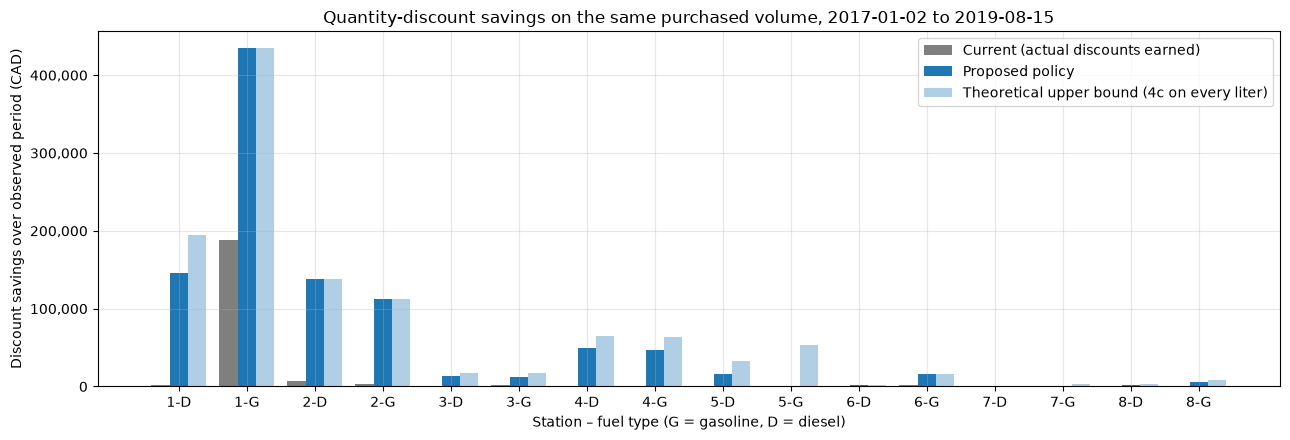

In [27]:
fig, ax = plt.subplots(figsize=(13, 4.5))
plot_df = rec.reset_index()
plot_df["label"] = plot_df["Station"].astype(str) + "-" + plot_df["Fuel Group"]
x = np.arange(len(plot_df)); w = 0.27
ax.bar(x - w, plot_df["Current_Savings_CAD"], w, label="Current (actual discounts earned)", color="tab:grey")
ax.bar(x, plot_df["Proposed_Savings_CAD"], w, label="Proposed policy", color="tab:blue")
ax.bar(x + w, plot_df["Upper_Bound_Savings_CAD"], w, label="Theoretical upper bound (4c on every liter)", color="tab:blue", alpha=0.35)
ax.set_xticks(x); ax.set_xticklabels(plot_df["label"]); ax.set_xlabel("Station – fuel type (G = gasoline, D = diesel)")
ax.set_ylabel("Discount savings over observed period (CAD)"); ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.set_title(f"Quantity-discount savings on the same purchased volume, {OBS_START.date()} to {OBS_END.date()}"); ax.legend(); plt.tight_layout(); plt.show()

### 3.4 Checking the policy against actual daily demand (simulation)

To confirm that the recommended trigger and quantity keep inventory above the reserve, the policy is replayed day by day against the observed daily consumption (incomplete days are filled with the station's average). Each morning the rule checks whether today's demand would push inventory below the reserve; if so, an order of the recommended quantity is delivered immediately (and capped at the remaining capacity). The simulation counts orders, the lowest inventory reached and the discount earned.

In [28]:
sim_rows = []
for key, r in rec.iterrows():
    d = daily_sf[(daily_sf["Station"] == key[0]) & (daily_sf["Fuel Group"] == key[1])].set_index("Date")
    demand = d["Consumption_L"].where(d["Complete"], r["Avg_Daily_L"])
    cap, reserve, q = r["Total_Capacity_L"], r["Reserve_7d_L"], r["Recommended_Qty_L"]
    level, n_orders, ordered, savings, min_level, stockout_days = cap, 0, 0.0, 0.0, cap, 0
    for dem in demand.values:
        if level - dem < reserve and q > 0:
            qty = min(q, cap - level)
            level += qty; n_orders += 1; ordered += qty; savings += qty * discount_rate(qty)
        level -= dem
        if level < 0:
            stockout_days += 1; level = 0
        min_level = min(min_level, level)
    sim_rows.append({"Station": key[0], "Fuel Group": key[1], "Sim_Days": len(demand), "Sim_Orders": n_orders,
                     "Sim_Avg_Order_L": ordered / max(n_orders, 1), "Sim_Volume_L": ordered, "Sim_Savings_CAD": savings,
                     "Sim_Min_Level_L": min_level, "Sim_Min_Days_Cover": min_level / r["Avg_Daily_L"], "Stockout_Days": stockout_days})
sim = pd.DataFrame(sim_rows).set_index(["Station", "Fuel Group"])
display(sim.style.format({"Sim_Avg_Order_L": "{:,.0f}", "Sim_Volume_L": "{:,.0f}", "Sim_Savings_CAD": "{:,.0f}",
                          "Sim_Min_Level_L": "{:,.0f}", "Sim_Min_Days_Cover": "{:.1f}"}))
print("Total simulated discount savings:", fmt_money(sim["Sim_Savings_CAD"].sum()),
      "| days with a stockout in the simulation:", int(sim["Stockout_Days"].sum()))

Total simulated discount savings: CAD 1,008,397 | days with a stockout in the simulation: 0


The figure below shows the simulated inventory path for four representative station/fuel pairs. Inventory saw-tooths between the reserve line (order trigger) and the reserve plus the order quantity, and never enters the red zone; each green triangle marks the inventory level at the moment an order is placed, always on or just above the reserve line. The last panel compares the station's *actual* gasoline inventory with the simulated policy over the same six months: the policy holds more fuel on average, orders far less often, and stays above the reserve that the actual operation breached repeatedly.

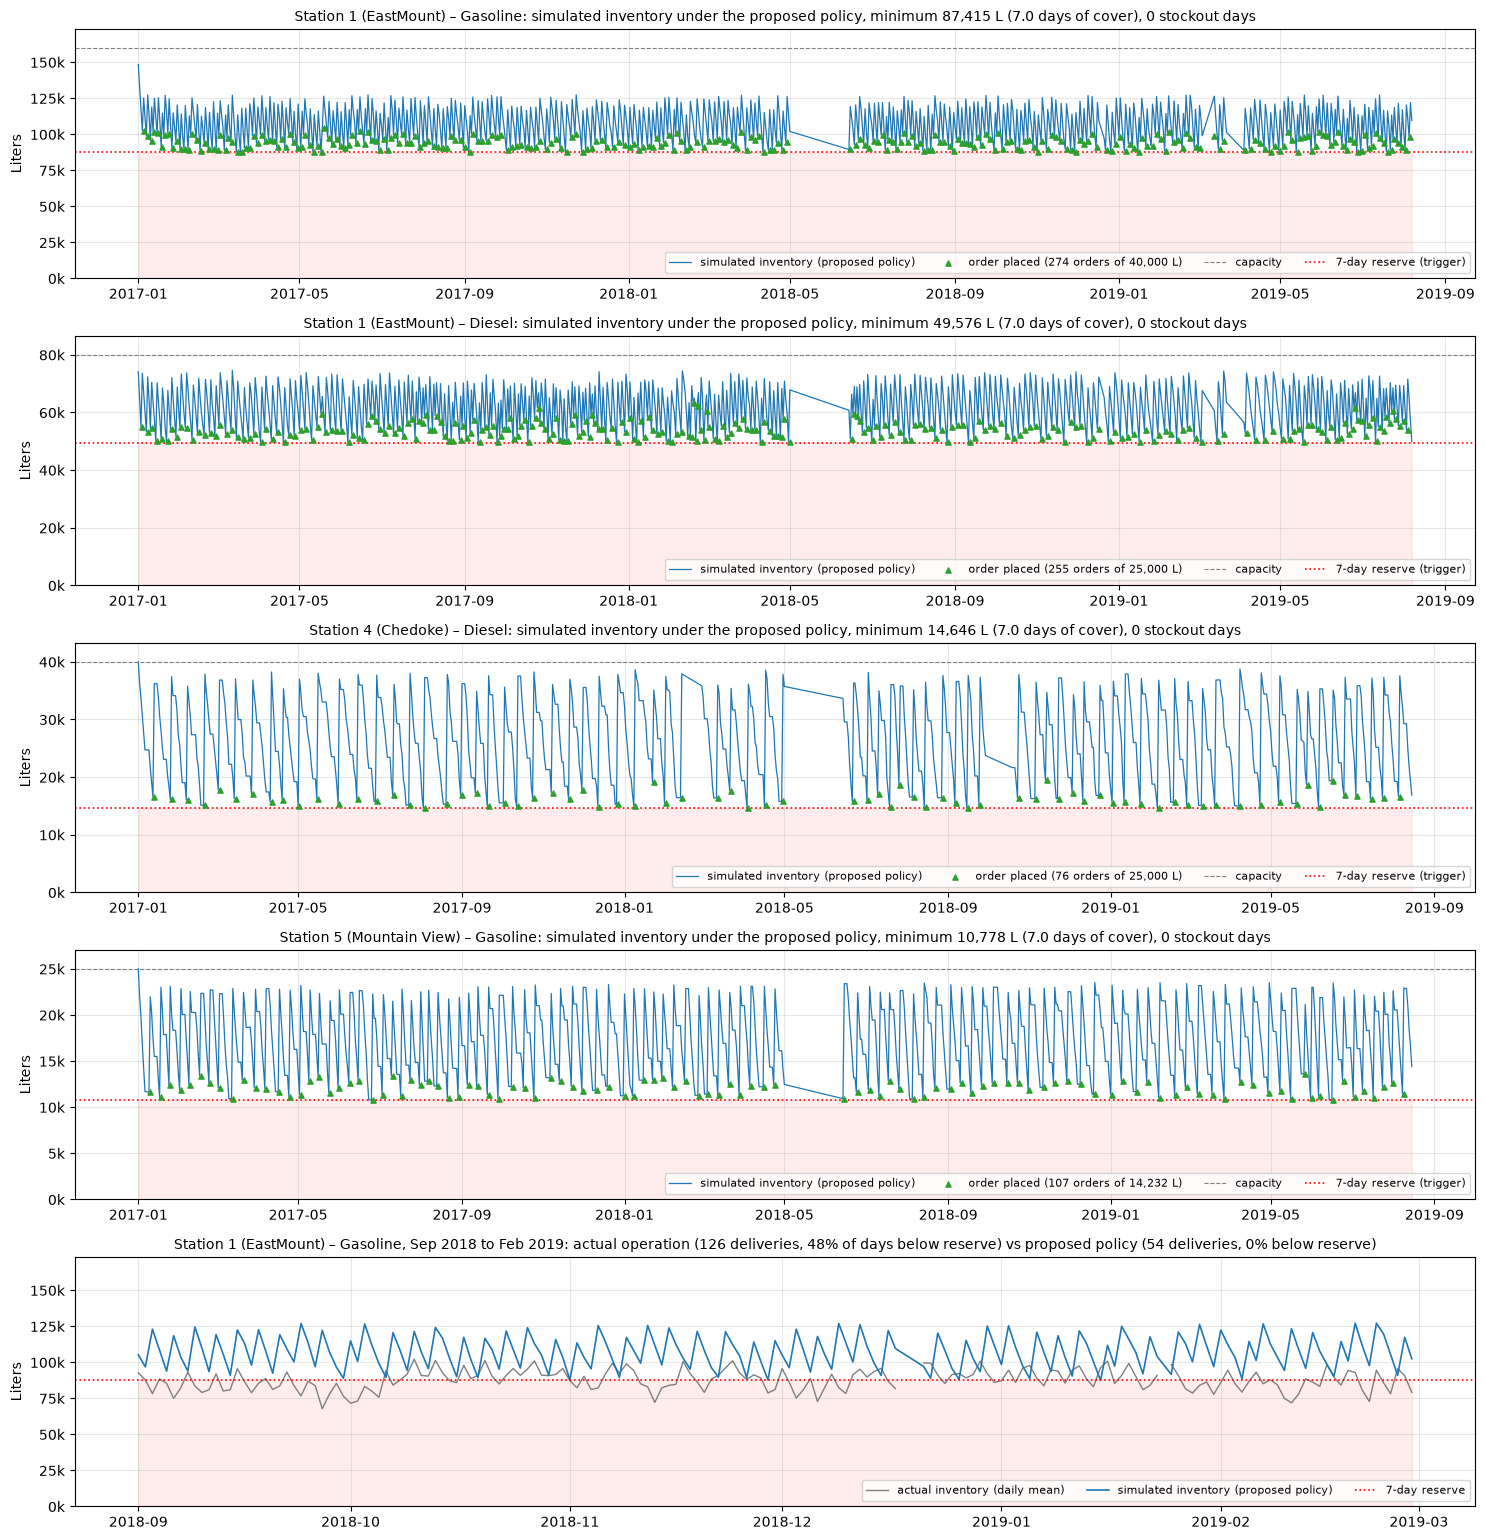

In [29]:
def simulate_path(key):
    # Day-by-day inventory under the recommended policy; returns a DataFrame indexed by date
    r = rec.loc[key]
    d = daily_sf[(daily_sf["Station"] == key[0]) & (daily_sf["Fuel Group"] == key[1])].set_index("Date")
    demand = d["Consumption_L"].where(d["Complete"], r["Avg_Daily_L"])
    cap, reserve, q = r["Total_Capacity_L"], r["Reserve_7d_L"], r["Recommended_Qty_L"]
    level, rows = cap, []
    for date, dem in demand.items():
        ordered, level_at_order = 0.0, np.nan
        if level - dem < reserve and q > 0:
            level_at_order = level                      # inventory at the moment the order is placed (>= reserve)
            ordered = min(q, cap - level); level += ordered
        level -= dem
        rows.append({"Date": date, "Level_L": max(level, 0), "Ordered_L": ordered, "Level_at_order_L": level_at_order})
    return pd.DataFrame(rows).set_index("Date")

show_keys = [(1, "G"), (1, "D"), (4, "D"), (5, "G")]
fig, axes = plt.subplots(len(show_keys) + 1, 1, figsize=(15, 3.1 * (len(show_keys) + 1)))
for ax, key in zip(axes, show_keys):
    path = simulate_path(key); r = rec.loc[key]
    ax.plot(path.index, path["Level_L"], lw=0.9, color="tab:blue", label="simulated inventory (proposed policy)")
    orders = path[path["Ordered_L"] > 0]
    ax.scatter(orders.index, orders["Level_at_order_L"], marker="^", s=14, color="tab:green", zorder=5,
               label=f"order placed ({len(orders)} orders of {r['Recommended_Qty_L']:,.0f} L)")
    ax.axhline(r["Total_Capacity_L"], ls="--", color="grey", lw=0.8, label="capacity")
    ax.axhline(r["Reserve_7d_L"], ls=":", color="red", lw=1.2, label="7-day reserve (trigger)")
    ax.fill_between(path.index, 0, r["Reserve_7d_L"], color="red", alpha=0.07)
    ax.set_ylim(0, r["Total_Capacity_L"] * 1.08); ax.set_ylabel("Liters")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
    ax.set_title(f"Station {key[0]} ({locations.set_index('Station').loc[key[0], 'Station Name']}) – {FUEL_NAME[key[1]]}: "
                 f"simulated inventory under the proposed policy, minimum {path['Level_L'].min():,.0f} L "
                 f"({path['Level_L'].min() / r['Avg_Daily_L']:.1f} days of cover), 0 stockout days", fontsize=10)
    ax.legend(fontsize=8, loc="lower right", ncol=4)

# Actual vs simulated, station 1 gasoline, six-month window
ax = axes[-1]; key = (1, "G"); r = rec.loc[key]
win = slice("2018-09-01", "2019-02-28")
actual = sf_level[key].resample("1D").mean().loc[win]
path = simulate_path(key).loc[win]
ax.plot(actual.index, actual.values, lw=1, color="tab:grey", label="actual inventory (daily mean)")
ax.plot(path.index, path["Level_L"], lw=1.2, color="tab:blue", label="simulated inventory (proposed policy)")
ax.axhline(r["Reserve_7d_L"], ls=":", color="red", lw=1.2, label="7-day reserve")
ax.fill_between(path.index, 0, r["Reserve_7d_L"], color="red", alpha=0.07)
ax.set_ylim(0, r["Total_Capacity_L"] * 1.08); ax.set_ylabel("Liters")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
n_act = len(events[(events["Station"] == 1) & (events["Fuel Group"] == "G") & events["Time"].between("2018-09-01", "2019-02-28")])
n_sim = int((path["Ordered_L"] > 0).sum())
ax.set_title(f"Station 1 (EastMount) – Gasoline, Sep 2018 to Feb 2019: actual operation ({n_act} deliveries, "
             f"{(actual < r['Reserve_7d_L']).mean():.0%} of days below reserve) vs proposed policy ({n_sim} deliveries, 0% below reserve)", fontsize=10)
ax.legend(fontsize=8, loc="lower right", ncol=3)
plt.tight_layout(); plt.show()

### 3.5 Demand variability and delivery-timing assumptions

The brief assumes immediate delivery, under which ordering exactly at the reserve can never cause a stockout. In reality a delivery may take a day or more. The table below shows how much demand can exceed its average (95th-percentile day and worst 7-day window) and what happens to the attainable discount if the trigger is raised by one day of 95th-percentile demand to cover a one-day lead time (available storage shrinks by the same amount).

In [30]:
var = rec[["Avg_Daily_L", "P95_Daily_L", "Max_7day_L", "Reserve_7d_L", "Available_L", "Recommended_Rate"]].copy()
var["P95_vs_Avg"] = var["P95_Daily_L"] / var["Avg_Daily_L"]
var["Worst_7d_vs_Reserve"] = var["Max_7day_L"] / var["Reserve_7d_L"]
var["Trigger_1day_lead_L"] = var["Reserve_7d_L"] + var["P95_Daily_L"]
var["Available_1day_lead_L"] = var["Available_L"] - var["P95_Daily_L"]
var["Rate_with_1day_lead"] = var["Available_1day_lead_L"].apply(lambda a: discount_rate(best_tier_qty(a)))
var["Tier_lost_with_lead_time"] = var["Rate_with_1day_lead"] < var["Recommended_Rate"]
display(var.style.format({"Avg_Daily_L": "{:,.0f}", "P95_Daily_L": "{:,.0f}", "Max_7day_L": "{:,.0f}", "Reserve_7d_L": "{:,.0f}",
                          "Available_L": "{:,.0f}", "Recommended_Rate": "{:.2f}", "P95_vs_Avg": "{:.2f}x", "Worst_7d_vs_Reserve": "{:.2f}x",
                          "Trigger_1day_lead_L": "{:,.0f}", "Available_1day_lead_L": "{:,.0f}", "Rate_with_1day_lead": "{:.2f}"}))

### 3.6 Findings – recommended ordering policy

* **The seven-day reserve is feasible everywhere** (no station/fuel pair has a reserve at or above capacity), but it consumes a large share of storage at the busy stations: 62 % of diesel capacity and 55 % of gasoline capacity at station 1, and 43 % of gasoline capacity at station 5. Station 7's two 5,000 L tanks leave only 4,100–4,900 L of room, so no discount tier is reachable there regardless of policy.
* **Recommended trigger and quantity** (section 3.3 table): order when inventory reaches the seven-day reserve and buy 40,000 L at station 1 (gasoline), station 2 (both fuels) and station 6 (gasoline); 25,000 L at station 1 (diesel), stations 3, 4 and 8 (both fuels) and station 6 (diesel); 15,000 L at station 5 (diesel); fill-up with no discount at station 5 (gasoline) and station 7. Station 5 gasoline misses the 2-cent tier by only 768 L of available storage – management could choose a 6.5-day reserve there to unlock roughly CAD 10,000 per year, but this is a deliberate relaxation of the brief's rule and is not assumed here.
* **Savings.** On the same volume actually purchased, the policy raises discount savings from CAD 205,979 to CAD 996,006 over the observed period (theoretical upper bound with 4 cents on every liter: CAD 1,163,068). The incremental saving is **CAD 790,027 over 956 days, about CAD 302,000 per year** – roughly 3.4 cents per liter on 10.6 million liters a year. The day-by-day simulation of the policy against actual demand (section 3.4) produces CAD 1,008,397 of discounts with **zero stockout days** and never less than 7.0 days of cover, confirming that the trigger and quantities are mutually consistent.
* **Fewer, larger deliveries.** Station 1 would move from 43 deliveries per month to about 18; station 2 from 20 to about 6; station 4 from 11 to about 5. Fewer deliveries also mean less receiving labour and fewer truck movements, which are not valued here.
* **Demand variability.** 95th-percentile daily demand is 1.3–1.6× the average at the busy stations and 2–7× at the quiet ones (where a single fleet fill-up dominates a day), and the worst observed week exceeded the seven-day reserve at every station (1.25–2.3× at the busy stations). Under the immediate-delivery assumption this cannot cause a stockout, but with a real one-day lead time the trigger should rise by one day of 95th-percentile demand; doing so costs one discount tier (3 → 2 cents) at station 1 diesel, station 3 gasoline and station 4 (both fuels), where storage is tight. Those four pairs are where the choice between discount and safety is real.
* **Very low-demand sites.** At station 6 diesel, station 7 diesel and station 8 diesel the recommended quantity implies 10–12 months between deliveries. The discount at stake is trivial (under CAD 1,000 a year combined), so in practice these should be capped at roughly 90 days of supply to avoid fuel-quality problems, forgoing the discount.

## 4. Business Question 3 – Do purchase prices differ by day of the week?

### 4.1 Rate by weekday, Monday to Friday – box plots

`Rate` = Gross Purchase Cost ÷ Amount Purchased (CAD per liter). Saturday has only 13 invoices and Sunday none, so the comparison is restricted to **Monday to Friday**, and the number of invoices is reported for each day.

**Decision rule used in this section.** A box plot shows the whole distribution of rates on a weekday, not just the average. If one weekday's box sits clearly *below* the others – lower most of the time, not just occasionally – the data support a cheaper day. If the boxes overlap in the same range and only the medians differ slightly, the day was cheaper only sometimes, and there is not enough evidence to expect it to be cheaper in the future.

,N_invoices,Mean_rate,Median_rate,Q1_rate,Q3_rate,Mean_order_L,Mean_discount
Weekday,,,,,,,
Monday,522,1.1849,1.0602,1.0213,1.1824,"9,082",0.0007
Tuesday,549,1.2563,1.0683,1.0312,1.2588,"12,772",0.0063
Wednesday,606,1.1956,1.0602,1.0213,1.1843,"9,071",0.0006
Thursday,338,1.1901,1.0602,1.0213,1.1816,"9,176",0.0008
Friday,803,1.2176,1.0677,1.0213,1.2371,"10,710",0.0044
Saturday,13,1.0721,1.0602,1.0213,1.0683,"9,673",0.0038


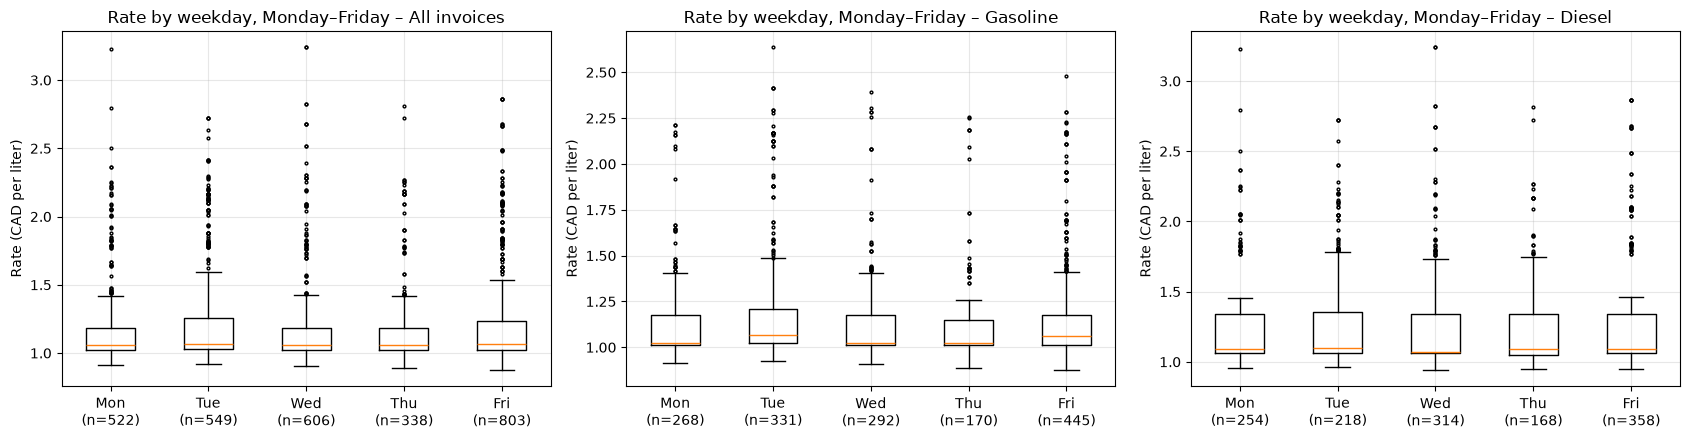

In [31]:
WEEKDAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
MON_FRI = WEEKDAYS[:5]
inv["Weekday"] = pd.Categorical(inv["Weekday"], categories=WEEKDAYS, ordered=True)
wk = inv.groupby("Weekday", observed=True).agg(N_invoices=("Invoice ID", "count"), Mean_rate=("Rate", "mean"),
                                                Median_rate=("Rate", "median"), Q1_rate=("Rate", lambda s: s.quantile(0.25)),
                                                Q3_rate=("Rate", lambda s: s.quantile(0.75)), Mean_order_L=("Liters", "mean"),
                                                Mean_discount=("Discount_per_L", "mean"))
display(wk.style.format({"Mean_rate": "{:.4f}", "Median_rate": "{:.4f}", "Q1_rate": "{:.4f}", "Q3_rate": "{:.4f}",
                         "Mean_order_L": "{:,.0f}", "Mean_discount": "{:.4f}"})
        .set_caption("Invoice rate (CAD/L) by weekday – all stations and fuels"))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
panels = [("All invoices", inv), ("Gasoline", inv[inv["Fuel Type"] == "G"]), ("Diesel", inv[inv["Fuel Type"] == "D"])]
for ax, (title, df) in zip(axes, panels):
    data = [df.loc[df["Weekday"] == d, "Rate"].values for d in MON_FRI]
    ax.boxplot(data, showfliers=True, flierprops={"ms": 2})
    ax.set_xticks(range(1, 6)); ax.set_xticklabels([f"{d[:3]}\n(n={len(x)})" for d, x in zip(MON_FRI, data)])
    ax.set_title(f"Rate by weekday, Monday–Friday – {title}"); ax.set_ylabel("Rate (CAD per liter)")
plt.tight_layout(); plt.show()

### 4.2 Why the raw comparison is misleading: prices move strongly over time

Cost per liter is dominated by the market price level, which was flat for months at a time and then roughly **doubled between March and May 2019**. The same supplier price applies to every station on a given day (the price is set network-wide), so any weekday pattern in the raw numbers could simply reflect *which weeks* happened to have orders on a given day.

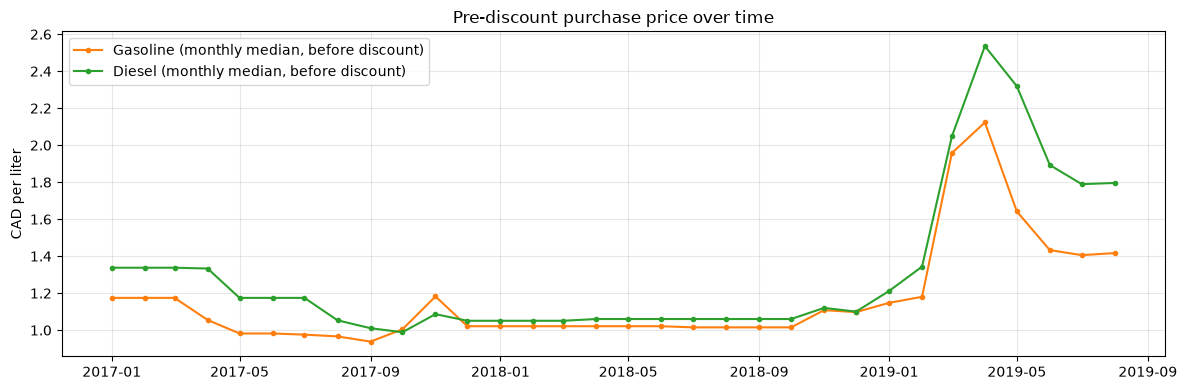

Across 844 date/fuel combinations with more than one invoice, the median within-day standard deviation of the pre-discount price is 0.00000 CAD/L – i.e. all stations pay the same price on the same day.


In [32]:
monthly = inv.set_index("Date").groupby("Fuel Type")["PreDiscount_per_L"].resample("MS").median().unstack("Fuel Type")
fig, ax = plt.subplots(figsize=(12, 4))
for fg, col in [("G", "tab:orange"), ("D", "tab:green")]:
    ax.plot(monthly.index, monthly[fg], marker="o", ms=3, color=col, label=f"{FUEL_NAME[fg]} (monthly median, before discount)")
ax.set_ylabel("CAD per liter"); ax.set_title("Pre-discount purchase price over time"); ax.legend(); plt.tight_layout(); plt.show()

same_day = inv.groupby(["Date", "Fuel Type"])["PreDiscount_per_L"].agg(["count", "std"]).query("count > 1")
print(f"Across {len(same_day)} date/fuel combinations with more than one invoice, the median within-day standard deviation of the "
      f"pre-discount price is {same_day['std'].median():.5f} CAD/L – i.e. all stations pay the same price on the same day.")

### 4.3 Like-for-like comparison

Three adjustments make the comparison fair:

1. use the **pre-discount price** (cost per liter + discount per liter) so quantity discounts cannot masquerade as a weekday effect;
2. compare **within fuel type**;
3. remove the time trend by expressing each invoice as a **deviation from the median pre-discount price of the same fuel in the same calendar month** (the "price residual", in cents per liter).

If a weekday were genuinely cheaper, its residual would be consistently negative across fuel types, stations and years.

Weekday,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday
Year,,,,,,
2017,-0.386000,1.323000,-0.821000,-0.386000,0.591000,-0.987000
2018,0.094000,1.729000,0.016000,-0.094000,1.188000,-0.972000
2019,-2.080000,-0.167000,2.566000,-2.188000,-0.248000,nan


Weekday,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday
Station,,,,,,
1,-0.269000,3.270000,0.399000,-1.050000,1.469000,-1.059000
2,-0.362000,-0.503000,-0.109000,-0.692000,1.025000,nan
3,-1.371000,-1.102000,1.056000,0.298000,0.323000,0.000000
4,0.018000,-0.702000,0.211000,-0.867000,-2.605000,nan
5,-4.113000,0.383000,-0.398000,-0.189000,-0.158000,nan
6,0.583000,0.003000,-0.153000,-0.051000,0.947000,nan
7,0.010000,-2.783000,-0.205000,3.190000,-3.895000,nan
8,-0.000000,2.327000,1.351000,0.436000,-1.613000,nan


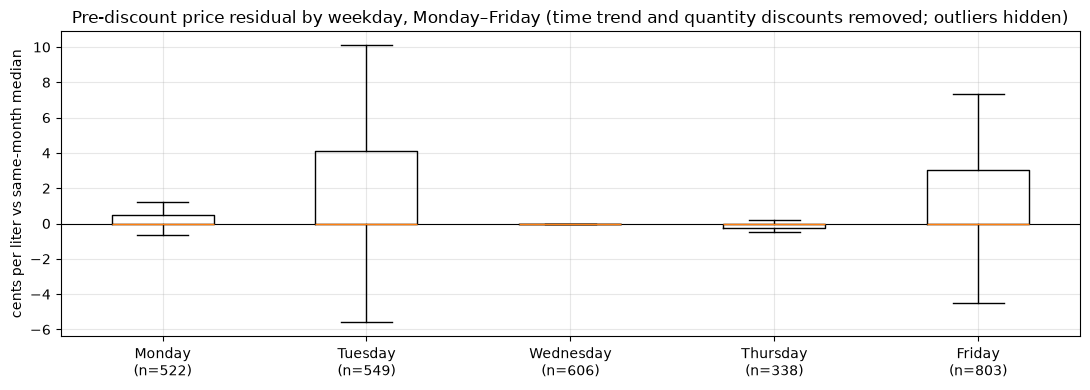

Kruskal-Wallis test of equal residual distributions across weekdays (days with >=20 invoices): H = 42.24, p = 0.000
Largest difference between weekday mean residuals: 1.70 cents per liter (cheapest: Thursday, most expensive: Tuesday)


In [33]:
inv["Month"] = inv["Date"].dt.to_period("M")
inv["Month_Median_PreDisc"] = inv.groupby(["Fuel Type", "Month"])["PreDiscount_per_L"].transform("median")
inv["Price_Residual_c"] = (inv["PreDiscount_per_L"] - inv["Month_Median_PreDisc"]) * 100
inv["Year"] = inv["Date"].dt.year

res_wk = inv.groupby(["Fuel Type", "Weekday"], observed=True)["Price_Residual_c"].agg(["count", "mean", "median"]).round(3)
display(res_wk.unstack("Fuel Type").style.set_caption("Price residual by weekday and fuel type (cents per liter vs same-month median)"))

res_year = inv.groupby(["Year", "Weekday"], observed=True)["Price_Residual_c"].mean().unstack("Weekday").round(3)
display(res_year.style.set_caption("Mean price residual (cents/L) by year and weekday – consistency check"))

res_station = inv.groupby(["Station", "Weekday"], observed=True)["Price_Residual_c"].mean().unstack("Weekday").round(3)
display(res_station.style.set_caption("Mean price residual (cents/L) by station and weekday"))

fig, ax = plt.subplots(figsize=(11, 4))
present = MON_FRI
ax.boxplot([inv.loc[inv["Weekday"] == d, "Price_Residual_c"].values for d in present], showfliers=False)
ax.set_xticks(range(1, len(present) + 1)); ax.set_xticklabels([f"{d}\n(n={(inv['Weekday']==d).sum()})" for d in present])
ax.axhline(0, color="black", lw=0.8); ax.set_ylabel("cents per liter vs same-month median")
ax.set_title("Pre-discount price residual by weekday, Monday–Friday (time trend and quantity discounts removed; outliers hidden)")
plt.tight_layout(); plt.show()

try:
    from scipy import stats
    groups = [inv.loc[inv["Weekday"] == d, "Price_Residual_c"].values for d in present if (inv["Weekday"] == d).sum() >= 20]
    h, p = stats.kruskal(*groups)
    print(f"Kruskal-Wallis test of equal residual distributions across weekdays (days with >=20 invoices): H = {h:.2f}, p = {p:.3f}")
except ImportError:
    print("scipy not available – statistical test skipped")

spread = inv[inv["Weekday"].isin([d for d in present if (inv['Weekday']==d).sum() >= 20])].groupby("Weekday", observed=True)["Price_Residual_c"].mean()
print(f"Largest difference between weekday mean residuals: {spread.max() - spread.min():.2f} cents per liter "
      f"(cheapest: {spread.idxmin()}, most expensive: {spread.idxmax()})")
WEEKDAY_SPREAD_C = spread.max() - spread.min()

### 4.4 One price per day: analysing at the day level and checking robustness

Every station pays the same price on the same day, so the 2,831 invoices are not 2,831 independent price observations – there are only as many independent observations as there are **purchase days**. Invoices are therefore collapsed to one price per fuel per day before testing. Two further robustness checks are made: (i) excluding March–August 2019, when prices were moving sharply within each month and a few invoices can dominate a monthly residual, and (ii) looking at the *direction* of day-to-day price changes by weekday (if prices were systematically cut on a given weekday, decreases would cluster on that day).

In [34]:
daily_price = (inv.groupby(["Fuel Type", "Date"])
                  .agg(PreDiscount_per_L=("PreDiscount_per_L", "median"), N=("Invoice ID", "count")).reset_index())
daily_price["Weekday"] = pd.Categorical(daily_price["Date"].dt.day_name(), categories=WEEKDAYS, ordered=True)
daily_price["Month"] = daily_price["Date"].dt.to_period("M")
daily_price["Residual_c"] = (daily_price["PreDiscount_per_L"]
                             - daily_price.groupby(["Fuel Type", "Month"])["PreDiscount_per_L"].transform("median")) * 100
stable = ~daily_price["Date"].between("2019-03-01", "2019-08-31")

def weekday_table(df, label):
    t = df.groupby("Weekday", observed=True)["Residual_c"].agg(Days="count", Mean_c="mean", Median_c="median", Std_c="std").round(3)
    t.columns = pd.MultiIndex.from_product([[label], t.columns])
    return t
tbl = pd.concat([weekday_table(daily_price, "All days (one price per fuel per day)"),
                 weekday_table(daily_price[stable], "Excluding Mar–Aug 2019")], axis=1)
display(tbl.style.set_caption("Pre-discount price residual (cents/L vs same-month median) by weekday, day-level"))

try:
    from scipy import stats
    for label, df in [("all days", daily_price), ("excluding Mar–Aug 2019", daily_price[stable])]:
        present_d = [d for d in WEEKDAYS if (df["Weekday"] == d).sum() >= 20]
        h, p = stats.kruskal(*[df.loc[df["Weekday"] == d, "Residual_c"].values for d in present_d])
        print(f"Kruskal-Wallis on day-level residuals, {label}: H = {h:.2f}, p = {p:.3f}")
except ImportError:
    pass

# Direction of day-to-day price changes by weekday
chg = daily_price.sort_values(["Fuel Type", "Date"]).copy()
chg["Change_c"] = chg.groupby("Fuel Type")["PreDiscount_per_L"].diff() * 100
chg = chg[chg["Change_c"].abs() > 0.05]
dir_tbl = (chg.assign(Direction=np.where(chg["Change_c"] > 0, "Increase", "Decrease"))
              .groupby(["Weekday", "Direction"], observed=True).size().unstack("Direction").fillna(0).astype(int))
dir_tbl["Mean change (c/L)"] = chg.groupby("Weekday", observed=True)["Change_c"].mean().round(2)
display(dir_tbl.style.set_caption("Days on which the network price changed versus the previous purchase day, by weekday"))

# Weekday premium / discount (excluding the volatile Mar–Aug 2019 period, weekdays with >= 20 purchase days)
stable_means = daily_price[stable].groupby("Weekday", observed=True)["Residual_c"].mean()
stable_means = stable_means[daily_price[stable]["Weekday"].value_counts() >= 20]
dear_day, cheap_day = stable_means.idxmax(), stable_means.idxmin()
premium_c = stable_means[dear_day] - stable_means.drop(dear_day).mean()
print(f"Most expensive weekday: {dear_day} ({stable_means[dear_day]:+.2f} c/L vs same-month median; {premium_c:.2f} c/L above the other weekdays). "
      f"Cheapest: {cheap_day} ({stable_means[cheap_day]:+.2f} c/L).")

# Which station/fuel pairs can choose their order day without losing their discount tier?
# (a) they order at most weekly, or (b) ordering one day early still leaves room for the recommended quantity
flex = rec[(rec["Days_between_orders"] >= 7) | (rec["Available_L"] - rec["Avg_Daily_L"] >= rec["Recommended_Qty_L"])].copy()
inflexible = rec.index.difference(flex.index).tolist()
dear_share = inv[inv["Weekday"] == dear_day].groupby(["Station", "Fuel Type"])["Liters"].sum().rename_axis(["Station", "Fuel Group"]) \
             / inv.groupby(["Station", "Fuel Type"])["Liters"].sum().rename_axis(["Station", "Fuel Group"])
flex["Share_bought_on_dear_day"] = dear_share.reindex(flex.index).fillna(0)
flex["Annual_saving_avoid_dear_day_CAD"] = flex["Annual_Volume_L"] * flex["Share_bought_on_dear_day"] * premium_c / 100
AVOID_SAVING = flex["Annual_saving_avoid_dear_day_CAD"].sum()
print(f"Station/fuel pairs with day-of-week flexibility: {len(flex)} of {len(rec)} (inflexible: {inflexible}).")
print(f"Currently {dear_share.reindex(flex.index).fillna(0).mul(flex['Annual_Volume_L']).sum() / flex['Annual_Volume_L'].sum():.0%} of their volume is bought on {dear_day}. "
      f"Moving those orders to another weekday would save about CAD {AVOID_SAVING:,.0f} per year – on top of, not instead of, the quantity-discount savings.")
display(flex[["Annual_Volume_L", "Share_bought_on_dear_day", "Annual_saving_avoid_dear_day_CAD"]]
        .style.format({"Annual_Volume_L": "{:,.0f}", "Share_bought_on_dear_day": "{:.0%}", "Annual_saving_avoid_dear_day_CAD": "{:,.0f}"}))

Kruskal-Wallis on day-level residuals, all days: H = 33.63, p = 0.000
Kruskal-Wallis on day-level residuals, excluding Mar–Aug 2019: H = 35.60, p = 0.000


Direction,Decrease,Increase,Mean change (c/L)
Weekday,,,
Monday,86,51,-1.590000
Tuesday,34,105,3.900000
Wednesday,115,40,-2.490000
Thursday,42,44,0.180000
Friday,53,92,1.080000
Saturday,5,4,-4.880000


Most expensive weekday: Tuesday (+1.85 c/L vs same-month median; 1.59 c/L above the other weekdays). Cheapest: Wednesday (+0.07 c/L).
Station/fuel pairs with day-of-week flexibility: 15 of 16 (inflexible: [(1, 'D')]).
Currently 27% of their volume is bought on Tuesday. Moving those orders to another weekday would save about CAD 39,538 per year – on top of, not instead of, the quantity-discount savings.


### 4.5 Findings – day of the week

* **Box-plot test (Monday–Friday): the boxes overlap and sit in the same range.** For all invoices, for gasoline alone and for diesel alone, the five weekday boxes cover the same range of rates and their medians differ by less than one cent per liter (medians 1.060–1.068 CAD/L overall). No weekday's box sits below the others. By the decision rule in section 4.1, the data **do not provide enough evidence that any weekday is cheaper**; a cheaper-looking day was cheaper only sometimes, not most of the time. A belief that "we should order on day X" is, on this evidence, a rumour.
* **Why the raw averages differ a little anyway.** The network pays one supplier price per day (within-day standard deviation across stations is zero), prices were flat for months and then doubled in spring 2019, and the weekday mix of orders and order sizes differs by station. Raw weekday means therefore move with *which weeks* had orders on that day, not with the day itself. After removing the time trend and quantity discounts, the median residual is exactly zero for every weekday.
* **The only residual pattern is in price *changes*, and it is too weak to act on.** Price increases cluster on Tuesdays (105 increases vs 34 decreases) and decreases on Wednesdays, so Tuesday's *mean* residual is about 1.6 cents per liter above the other weekdays (statistically detectable, Kruskal–Wallis p < 0.001). But Tuesday's box still overlaps the others completely, the effect is absent in 2019 when prices were volatile, and the data are altered. By the box-plot rule this is "slightly different but in the same range", so we do not recommend a preferred day.
* **Savings.** Because no preferred day is supported, **no weekday savings are added to the recommendations**. For completeness, section 4.4 shows the ceiling: if the Tuesday pattern were real and persisted, moving Tuesday orders at the 15 flexible station/fuel pairs would be worth at most about CAD 40,000 per year, separate from the quantity-discount savings because the comparison uses pre-discount prices. Station 1 diesel cannot shift its order day without losing a discount tier.
* **Limitations.** Only 13 Saturday invoices and no Sunday invoices; one price per day means the effective sample is the number of purchase days, not invoices; and the strong 2019 price trend dominates any raw comparison.

## 5. Business Question 4 – Feasibility of replacing tanks

### 5.1 Method

At each station, every existing tank is evaluated as a candidate for replacement with a **60,000 L tank storing the same fuel type**. Only replacements that increase capacity are considered; tanks of 60,000 L or more (the two 70,000 L tanks at station 2) are reported as "no increase". For each candidate:

* net increase in storage = 60,000 − existing capacity;
* new available storage = new total capacity − the same seven-day reserve;
* new attainable discount and the **incremental annual savings relative to the improved policy with existing tanks** (section 3.3) = annual volume × (new discount − current-policy discount);
* five-year net benefit = 5 × annual incremental savings − replacement cost (additional operating costs assumed to be zero, see assumptions);
* simple payback = replacement cost ÷ annual incremental savings (reported where savings are positive).

Annual volume is the observed purchased volume scaled to 365 days (observation period of 956 days). Prices, discounts, demand and operating costs are held constant at these baseline values over the five-year horizon. The best single-tank replacement per station is then selected.

In [35]:
cand_rows = []
for _, t in tanks.iterrows():
    key = (t["Station"], t["Fuel Group"])
    r = rec.loc[key]
    increase = REPLACEMENT_TANK_L - t["Tank Capacity"]
    row = {"Station": t["Station"], "Tank ID": t["Tank ID"], "Fuel Group": t["Fuel Group"], "Fuel": FUEL_NAME[t["Fuel Group"]],
           "Existing_Capacity_L": t["Tank Capacity"], "Net_Increase_L": max(increase, 0),
           "Station_Capacity_Before_L": r["Total_Capacity_L"], "Reserve_7d_L": r["Reserve_7d_L"],
           "Available_Before_L": r["Available_L"], "Rate_Before": r["Recommended_Rate"], "Annual_Volume_L": r["Annual_Volume_L"]}
    if increase <= 0:
        row.update({"Capacity_After_L": r["Total_Capacity_L"], "Available_After_L": r["Available_L"], "Rate_After": r["Recommended_Rate"],
                    "Incremental_Annual_Savings_CAD": 0.0, "Note": "60,000 L tank is not larger than existing tank – no increase"})
    else:
        cap_after = r["Total_Capacity_L"] + increase
        avail_after = cap_after - r["Reserve_7d_L"]
        rate_after = discount_rate(best_tier_qty(avail_after)) if avail_after > 0 else 0.0
        row.update({"Capacity_After_L": cap_after, "Available_After_L": avail_after, "Rate_After": rate_after,
                    "Incremental_Annual_Savings_CAD": r["Annual_Volume_L"] * (rate_after - r["Recommended_Rate"]), "Note": ""})
    cand_rows.append(row)
candidates = pd.DataFrame(cand_rows)
candidates["Note"] = candidates["Note"].fillna("")
candidates["Five_Year_Net_CAD"] = EVAL_YEARS * candidates["Incremental_Annual_Savings_CAD"] - np.where(candidates["Net_Increase_L"] > 0, REPLACEMENT_COST, 0)
candidates["Payback_Years"] = np.where(candidates["Incremental_Annual_Savings_CAD"] > 0,
                                       REPLACEMENT_COST / candidates["Incremental_Annual_Savings_CAD"].replace(0, np.nan), np.nan)
display(candidates.style.format({"Existing_Capacity_L": "{:,.0f}", "Net_Increase_L": "{:,.0f}", "Station_Capacity_Before_L": "{:,.0f}",
                                 "Reserve_7d_L": "{:,.0f}", "Available_Before_L": "{:,.0f}", "Rate_Before": "{:.2f}", "Annual_Volume_L": "{:,.0f}",
                                 "Capacity_After_L": "{:,.0f}", "Available_After_L": "{:,.0f}", "Rate_After": "{:.2f}",
                                 "Incremental_Annual_Savings_CAD": "{:,.0f}", "Five_Year_Net_CAD": "{:,.0f}", "Payback_Years": "{:.1f}"}, na_rep="–")
        .set_caption("Every tank evaluated as a candidate for replacement by a 60,000 L tank (base case: CAD 250,000 per tank)"))

,Station,Tank ID,Fuel Group,Fuel,Existing_Capacity_L,Net_Increase_L,Station_Capacity_Before_L,Reserve_7d_L,Available_Before_L,Rate_Before,Annual_Volume_L,Capacity_After_L,Available_After_L,Rate_After,Incremental_Annual_Savings_CAD,Note,Five_Year_Net_CAD,Payback_Years
0,1,T10,G,Gasoline,"40,000","20,000","160,000","87,385","72,615",0.04,"4,148,710","180,000","92,615",0.04,0,,"-250,000",–
1,1,T11,G,Gasoline,"40,000","20,000","160,000","87,385","72,615",0.04,"4,148,710","180,000","92,615",0.04,0,,"-250,000",–
2,1,T12,D,Diesel,"40,000","20,000","80,000","49,563","30,437",0.03,"1,860,300","100,000","50,437",0.04,"18,603",,"-156,985",13.4
3,1,T13,G,Gasoline,"40,000","20,000","160,000","87,385","72,615",0.04,"4,148,710","180,000","92,615",0.04,0,,"-250,000",–
4,1,T14,G,Gasoline,"40,000","20,000","160,000","87,385","72,615",0.04,"4,148,710","180,000","92,615",0.04,0,,"-250,000",–
5,1,T15,D,Diesel,"40,000","20,000","80,000","49,563","30,437",0.03,"1,860,300","100,000","50,437",0.04,"18,603",,"-156,985",13.4
6,2,T16,G,Gasoline,"70,000",0,"110,000","22,024","87,976",0.04,"1,077,633","110,000","87,976",0.04,0,"60,000 L tank is not larger than existing tank – no increase",0,–
7,2,T17,D,Diesel,"40,000","20,000","110,000","28,685","81,315",0.04,"1,321,369","130,000","101,315",0.04,0,,"-250,000",–
8,2,T18,G,Gasoline,"40,000","20,000","110,000","22,024","87,976",0.04,"1,077,633","130,000","107,976",0.04,0,,"-250,000",–
9,2,T19,D,Diesel,"70,000",0,"110,000","28,685","81,315",0.04,"1,321,369","110,000","81,315",0.04,0,"60,000 L tank is not larger than existing tank – no increase",0,–


In [36]:
# Best single replacement per station
best = (candidates[candidates["Net_Increase_L"] > 0]
        .sort_values(["Station", "Incremental_Annual_Savings_CAD", "Net_Increase_L"], ascending=[True, False, False])
        .groupby("Station").head(1).set_index("Station"))
best["Days_cover_at_full_before"] = best["Station_Capacity_Before_L"] / (best["Reserve_7d_L"] / RESERVE_DAYS)
best["Days_cover_at_full_after"] = best["Capacity_After_L"] / (best["Reserve_7d_L"] / RESERVE_DAYS)
show = ["Tank ID", "Fuel", "Existing_Capacity_L", "Net_Increase_L", "Available_Before_L", "Available_After_L", "Rate_Before", "Rate_After",
        "Annual_Volume_L", "Incremental_Annual_Savings_CAD", "Five_Year_Net_CAD", "Payback_Years", "Days_cover_at_full_before", "Days_cover_at_full_after"]
display(best[show].style.format({"Existing_Capacity_L": "{:,.0f}", "Net_Increase_L": "{:,.0f}", "Available_Before_L": "{:,.0f}", "Available_After_L": "{:,.0f}",
                                 "Rate_Before": "{:.2f}", "Rate_After": "{:.2f}", "Annual_Volume_L": "{:,.0f}", "Incremental_Annual_Savings_CAD": "{:,.0f}",
                                 "Five_Year_Net_CAD": "{:,.0f}", "Payback_Years": "{:.1f}", "Days_cover_at_full_before": "{:.0f}", "Days_cover_at_full_after": "{:.0f}"}, na_rep="–")
        .set_caption("Best single-tank replacement per station (base case CAD 250,000, 5-year horizon)"))
no_increase = candidates[candidates["Net_Increase_L"] == 0][["Station", "Tank ID", "Fuel", "Existing_Capacity_L"]]
print("Tanks for which a 60,000 L replacement would NOT increase capacity:")
display(no_increase)

,Tank ID,Fuel,Existing_Capacity_L,Net_Increase_L,Available_Before_L,Available_After_L,Rate_Before,Rate_After,Annual_Volume_L,Incremental_Annual_Savings_CAD,Five_Year_Net_CAD,Payback_Years,Days_cover_at_full_before,Days_cover_at_full_after
Station,,,,,,,,,,,,,,
1,T12,Diesel,"40,000","20,000","30,437","50,437",0.03,0.04,"1,860,300","18,603","-156,985",13.4,11,14
2,T17,Diesel,"40,000","20,000","81,315","101,315",0.04,0.04,"1,321,369",0,"-250,000",–,27,32
3,T21,Diesel,"30,000","30,000","26,853","56,853",0.03,0.04,"164,867","1,649","-241,757",151.6,67,133
4,T23,Diesel,"40,000","20,000","25,393","45,393",0.03,0.04,"623,275","6,233","-218,836",40.1,19,29
5,T25,Gasoline,"25,000","35,000","14,232","49,232",0.00,0.04,"514,174","20,567","-147,165",12.2,16,39
6,T28,Diesel,"30,000","30,000","29,528","59,528",0.03,0.04,"20,858",209,"-248,957",1198.6,445,890
7,T29,Gasoline,"5,000","55,000","4,134","59,134",0.00,0.04,"35,722","1,429","-242,856",175.0,40,485
8,T32,Gasoline,"40,000","20,000","38,300","58,300",0.03,0.04,"79,316",793,"-246,034",315.2,165,247


Tanks for which a 60,000 L replacement would NOT increase capacity:


,Station,Tank ID,Fuel,Existing_Capacity_L
6,2,T16,Gasoline,70000
9,2,T19,Diesel,70000


### 5.2 Sensitivity: replacement cost and demand

Replacement cost is varied between CAD 150,000 and 350,000. Demand is varied by ±20 %, which changes the seven-day reserve (and therefore available storage and the attainable discount) as well as the annual volume on which the discount is earned. The table shows the five-year net benefit of the best replacement at each station under each combination.

In [37]:
def evaluate_station(st, demand_mult, cost):
    '''Five-year net benefit of the best single replacement at a station under a demand multiplier and replacement cost.'''
    best_val, best_tank = -np.inf, None
    for _, t in tanks[tanks["Station"] == st].iterrows():
        key = (st, t["Fuel Group"]); r = rec.loc[key]
        increase = REPLACEMENT_TANK_L - t["Tank Capacity"]
        if increase <= 0:
            continue
        reserve = r["Reserve_7d_L"] * demand_mult
        vol = r["Annual_Volume_L"] * demand_mult
        avail_before = r["Total_Capacity_L"] - reserve
        avail_after = avail_before + increase
        rate_before = discount_rate(best_tier_qty(avail_before)) if avail_before > 0 else 0.0
        rate_after = discount_rate(best_tier_qty(avail_after)) if avail_after > 0 else 0.0
        annual = vol * (rate_after - rate_before)
        net = EVAL_YEARS * annual - cost
        if net > best_val:
            best_val, best_tank = net, f"{t['Tank ID']} ({FUEL_NAME[t['Fuel Group']]})"
    return best_val, best_tank

sens = {}
for cost in [150000, 250000, 350000]:
    for mult, lab in [(0.8, "demand -20%"), (1.0, "base demand"), (1.2, "demand +20%")]:
        sens[(f"CAD {cost:,}", lab)] = {st: evaluate_station(st, mult, cost)[0] for st in STATIONS}
sens = pd.DataFrame(sens).rename_axis(index="Station")
display(sens.style.format("{:,.0f}").background_gradient(cmap="RdYlGn", vmin=-350000, vmax=50000)
        .set_caption("Five-year net benefit (CAD) of the best single-tank replacement per station"))
print("Best tank under +20% demand and CAD 150,000 cost:", {int(st): evaluate_station(st, 1.2, 150000)[1] for st in STATIONS})
print("Demand multiplier needed for the best station to break even at CAD 250,000 (searched 1.0x–3.0x):")
for st in STATIONS:
    m = next((m for m in np.arange(1.0, 3.01, 0.05) if evaluate_station(st, m, REPLACEMENT_COST)[0] >= 0), None)
    print(f"  station {st}: {'%.2fx' % m if m else 'no break-even below 3x demand'}")

Best tank under +20% demand and CAD 150,000 cost: {1: 'T12 (Diesel)', 2: 'T17 (Diesel)', 3: 'T21 (Diesel)', 4: 'T23 (Diesel)', 5: 'T25 (Gasoline)', 6: 'T28 (Diesel)', 7: 'T29 (Gasoline)', 8: 'T32 (Gasoline)'}
Demand multiplier needed for the best station to break even at CAD 250,000 (searched 1.0x–3.0x):
  station 1: 1.35x
  station 2: 3.00x
  station 3: no break-even below 3x demand
  station 4: no break-even below 3x demand
  station 5: no break-even below 3x demand
  station 6: no break-even below 3x demand
  station 7: no break-even below 3x demand
  station 8: no break-even below 3x demand


### 5.3 Findings – tank replacement

* **No single-tank replacement pays back within five years at CAD 250,000.** The strongest cases are **station 1 (replace diesel tank T12 or T15, 40,000 → 60,000 L)** – unlocking the 4-cent tier on about 1.86 million liters of diesel a year for CAD 18,600 per year, payback 13.4 years, five-year net −CAD 157,000 – and **station 5 (replace gasoline tank T25, 25,000 → 60,000 L)** – taking gasoline from no discount to 4 cents on 514,000 L a year, CAD 20,600 per year, payback 12.2 years, five-year net −CAD 147,000. Every other station is worth less than CAD 6,300 per year.
* **Station 2 gains nothing** because both fuels already reach the 4-cent tier with existing tanks, and its two 70,000 L tanks (T16, T19) are already larger than the 60,000 L replacement. Stations 6, 7 and 8 have too little demand for any discount to matter.
* **Sensitivity.** At CAD 150,000 per tank the base-demand net benefit is still negative everywhere (best: station 1 at −CAD 57,000). Station 1 turns positive only with demand 20 % higher *and* a CAD 150,000 cost (+CAD 73,000 over five years); at CAD 250,000 it needs demand 35 % above the observed level to break even. If the missing 2019 diesel invoices mean station 1's true diesel volume is about 25 % higher than invoiced, its payback shortens to roughly 11 years – still well beyond five.
* **Non-financial benefits.** A larger tank also raises days of cover at full inventory (station 1 diesel from 11 to 14 days, station 5 gasoline from 16 to 39 days), which reduces the stockout exposure identified in Question 1. This is the better argument for station 5, but it is cheaper to achieve the same protection by ordering earlier.
* **What the data cannot resolve:** whether a 60,000 L tank physically fits the site and local permitting, the downtime and lost sales during replacement, soil conditions, and any change in operating or insurance costs. These would all need a site survey before a decision.

## 6. Summary table by station and fuel type

Current ordering performance, proposed replenishment trigger and order quantity, current and proposed discount savings over the same observed period and volume, and the estimated incremental savings.

In [38]:
summary = pd.DataFrame({
    "Station name": [locations.set_index("Station").loc[s, "Station Name"] for s in rec.index.get_level_values(0)],
    "Total capacity (L)": rec["Total_Capacity_L"],
    "Avg daily consumption (L)": rec["Avg_Daily_L"],
    "Current orders (count)": perf["N_Orders"],
    "Current avg order (L)": perf["Avg_Order_L"],
    "Current orders / month": perf["Orders_per_Month"],
    "Current avg discount (c/L)": perf["Avg_Discount_cents_per_L"],
    "Current discount savings (CAD)": rec["Current_Savings_CAD"],
    "Proposed trigger = 7-day reserve (L)": rec["Trigger_L"],
    "Proposed order qty (L)": rec["Recommended_Qty_L"],
    "Proposed discount (c/L)": rec["Recommended_Rate"] * 100,
    "Proposed orders / month": 30.44 / rec["Days_between_orders"],
    "Proposed discount savings (CAD)": rec["Proposed_Savings_CAD"],
    "Incremental savings (CAD, observed period)": rec["Incremental_Savings_CAD"],
    "Incremental savings (CAD / year)": rec["Incremental_Savings_per_Year_CAD"],
}, index=rec.index)
summary.index = summary.index.set_levels(summary.index.levels[1].map(FUEL_NAME), level=1)
summary.loc[("Network total", ""), :] = summary.sum(numeric_only=True)
summary.loc[("Network total", ""), ["Station name", "Total capacity (L)", "Avg daily consumption (L)", "Current avg order (L)",
                                      "Current avg discount (c/L)", "Proposed trigger = 7-day reserve (L)", "Proposed order qty (L)",
                                      "Proposed discount (c/L)"]] = np.nan
display(summary.style.format({c: "{:,.0f}" for c in summary.columns if c != "Station name"} |
                             {"Current orders / month": "{:.1f}", "Proposed orders / month": "{:.1f}",
                              "Current avg discount (c/L)": "{:.2f}", "Proposed discount (c/L)": "{:.0f}"}, na_rep="")
        .set_caption(f"Summary by station and fuel type – observed period {OBS_START.date()} to {OBS_END.date()} ({OBS_DAYS} days)"))
summary.to_csv("summary_by_station_fuel.csv")

## 7. Limitations of the data and analysis

* **Inferred, not metered, consumption.** Daily consumption is derived from differences between tank-gauge readings. Sales during the 15-minute delivery intervals and during data gaps are unobserved, gauge noise adds variance, and a handful of large unexplained level drops (e.g. tank T15, 3 Dec 2018) were excluded rather than interpreted. Agreement between gauge-inferred deliveries and invoiced volume is within a few percent for most station/fuel pairs, which supports the approach.
* **Possibly frozen gauges.** Some tank-days show no change in reading over a full day of coverage (for example 170 days for tank T20 at station 3, and 6–11 days for station 2's tanks in May–July 2019). These may be genuine zero-sales days or a stuck gauge; they are kept as zero consumption, so average demand at stations 2 and 3 may be slightly understated. This does not change any attainable discount tier.
* **Data gaps.** All tanks stop reporting from 1 May to 14 June 2018; station 3 is missing about seven months in total; station 7 only starts in June 2017. Averages are based on complete days only, so seasonal coverage is uneven.
* **Linking invoices to tanks.** Invoices are at station × fuel-type level and several invoices can share a date, so individual invoices cannot be matched one-to-one to gauge-detected deliveries. All invoice analysis is therefore done at station × fuel level, which avoids double counting across tanks.
* **Immediate delivery and fully usable capacity** are modelling assumptions from the brief. Real deliveries have lead times, tanks cannot be filled to 100 % (vapour space) and trucks deliver in compartment sizes, so the practical order quantity is somewhat below the figures reported here; section 3.5 shows how a one-day lead time affects the attainable discount.
* **Fuel ageing.** Where demand is very low (stations 6, 7 and 8) the recommended order quantity implies several months between deliveries. Diesel and gasoline degrade in storage, so operational limits on storage time may override the pure discount logic.
* **Stationarity.** Savings are annualised from a 956-day window and held constant for five years. Demand, prices and the discount schedule may change; the sensitivity analysis in section 5.2 covers ±20 % demand and three replacement-cost levels only.
* **Tank replacement costs** exclude soil contamination, downtime during replacement and any additional operating costs (assumed zero). Site constraints (space for a larger excavation, permits, environmental approvals) cannot be assessed from these datasets.
* **Location data.** Station 8's coordinates do not match its Hamilton address; coordinates are not used in any calculation.

## 8. References

* The pandas development team. *pandas documentation* (groupby, resample, merge). https://pandas.pydata.org/docs/
* Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, 9(3), 90–95. https://matplotlib.org/
* Harris, C. R. et al. (2020). Array programming with NumPy. *Nature*, 585, 357–362.
* Virtanen, P. et al. (2020). SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nature Methods*, 17, 261–272 (Kruskal–Wallis test, `scipy.stats.kruskal`).
* Chopra, S., & Meindl, P. (2016). *Supply Chain Management: Strategy, Planning, and Operation* (6th ed.), Pearson – reorder-point / safety-stock logic and quantity-discount ordering.
* Brealey, R., Myers, S., & Allen, F. (2020). *Principles of Corporate Finance* (13th ed.), McGraw-Hill – simple payback period.
* Project brief: *Fuel Inventory Management Project – Project Description (Revised)*, course handout.